# TASK 1: DATA UNDERSTANDING AND PREPROCESSING

In [2]:
# Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load the Dataset

In [5]:
df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

In [6]:
# Initial Dataset Inspection

In [7]:
# Preview the dataset
display(df.head())

print("\nFirst 10 Column Names:")
print(df.columns[:10].tolist())

print("\nTarget Column:")
print("diseases")

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0



First 10 Column Names:
['diseases', 'anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness']

Target Column:
diseases


In [8]:
# Dataset Structure

In [9]:
print("\nNumber of Rows:")
print(df.shape[0])

print("\nNumber of Columns:")
print(df.shape[1])

print("\nNumber of Symptom Features:")
print(df.shape[1] - 1)

print("\nData Type Distribution:")
print(df.dtypes.value_counts())


Number of Rows:
96088

Number of Columns:
231

Number of Symptom Features:
230

Data Type Distribution:
int64     230
object      1
Name: count, dtype: int64


In [10]:
# Initial Data Quality Assessment 

In [11]:
print("INITIAL DATA QUALITY ASSESSMENT")

print("\nDataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nNumber of Disease Classes:")
print(df["diseases"].nunique())

print("\nTarget Missing Values:")
print(df["diseases"].isnull().sum())

INITIAL DATA QUALITY ASSESSMENT

Dataset Shape:
(96088, 231)

Total Missing Values:
0

Duplicate Rows:
0

Number of Disease Classes:
100

Target Missing Values:
0


In [12]:
# Symptom Feature Validation

In [13]:
symptom_cols = df.columns.drop("diseases")

unique_symptom_values = pd.unique(
    df[symptom_cols].values.ravel()
)

print("Unique values found in symptom features:")
print(
    np.sort(unique_symptom_values)
)

print("\nNumber of Symptom Features:")
print(len(symptom_cols))

Unique values found in symptom features:
[0 1]

Number of Symptom Features:
230


In [14]:
# Disease Class Assessment

In [15]:
disease_counts = (
    df["diseases"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of Disease Classes:")
print(len(disease_counts))

print("\nDisease Class Size Summary:")
display(
    disease_counts.describe().to_frame(
        name="Number of Cases"
    ).round(2)
)

print("\n10 Most Frequent Diseases:")
display(
    disease_counts
    .head(10)
    .to_frame(name="Number of Cases")
)

Number of Disease Classes:
100

Disease Class Size Summary:


,Number of Cases
count,100.00
mean,960.88
std,191.59
min,803.00
25%,811.00
50%,824.00
75%,1207.25
max,1219.00



10 Most Frequent Diseases:


,Number of Cases
diseases,
cystitis,1219
vulvodynia,1218
nose disorder,1218
complex regional pain syndrome,1217
spondylosis,1216
vaginal cyst,1215
conjunctivitis due to allergy,1215
peripheral nerve disorder,1215
esophagitis,1215


In [16]:
# Target Variable Distribution

In [17]:
target_distribution = (
    df["diseases"]
    .value_counts()
    .rename_axis("Disease")
    .reset_index(name="Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(df)
    * 100
)

print("Target Variable: diseases")
print("Number of Disease Classes:", df["diseases"].nunique())

print("\nTarget Distribution Summary:")
display(
    target_distribution.head(15).round(2)
)

Target Variable: diseases
Number of Disease Classes: 100

Target Distribution Summary:


,Disease,Count,Percentage
0,cystitis,1219,1.27
1,vulvodynia,1218,1.27
2,nose disorder,1218,1.27
3,complex regional pain syndrome,1217,1.27
4,spondylosis,1216,1.27
5,vaginal cyst,1215,1.26
6,conjunctivitis due to allergy,1215,1.26
7,peripheral nerve disorder,1215,1.26
8,esophagitis,1215,1.26
9,hypoglycemia,1215,1.26


In [18]:
# Target Class Balance

In [19]:
print("Largest Disease Class:")
print(target_distribution.iloc[0])

print("\nSmallest Disease Class:")
print(target_distribution.iloc[-1])

print("\nMean Number of Cases per Disease:")
print(round(target_distribution["Count"].mean(), 2))

print("\nMedian Number of Cases per Disease:")
print(round(target_distribution["Count"].median(), 2))

Largest Disease Class:
Disease       cystitis
Count             1219
Percentage    1.268629
Name: 0, dtype: object

Smallest Disease Class:
Disease       temporary or benign blood in urine
Count                                        803
Percentage                              0.835692
Name: 99, dtype: object

Mean Number of Cases per Disease:
960.88

Median Number of Cases per Disease:
824.0


In [20]:
# Descriptive Statistics of Symptom Features

In [21]:
symptom_descriptive_stats = df[symptom_cols].describe()

print("Descriptive Statistics for Symptom Features")
display(symptom_descriptive_stats)

Descriptive Statistics for Symptom Features


,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
count,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,...,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000,96088.000000
mean,0.028994,0.029900,0.097588,0.041087,0.098285,0.062661,0.035270,0.041389,0.045510,0.028120,...,0.010886,0.015486,0.004433,0.004184,0.004215,0.010355,0.004433,0.006223,0.004267,0.006296
std,0.167791,0.170311,0.296758,0.198493,0.297701,0.242354,0.184462,0.199190,0.208422,0.165317,...,0.103766,0.123475,0.066437,0.064546,0.064786,0.101232,0.066437,0.078643,0.065183,0.079100
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
# Create a working copy
df_clean = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


In [23]:
print("Shape Before Cleaning:", df_clean.shape)

Shape Before Cleaning: (96088, 231)


In [24]:
# Reproducibility
np.random.seed(42)

df_raw = df_clean.copy()

# Introduce 1% missing values into symptom columns only
symptom_cols = df_raw.columns[1:]

for col in symptom_cols:
    missing_index = df_raw.sample(frac=0.01).index
    df_raw.loc[missing_index, col] = np.nan

print("Artificial missing values introduced.")

Artificial missing values introduced.


In [25]:
df_raw.isnull().sum().sort_values(ascending=False).head(10)

anxiety and nervousness             961
depression                          961
shortness of breath                 961
sharp chest pain                    961
depressive or psychotic symptoms    961
dizziness                           961
insomnia                            961
leg pain                            961
abnormal involuntary movements      961
chest tightness                     961
dtype: int64

In [26]:
# Introduce duplicate records 

In [27]:
duplicate_rows = df_raw.sample(frac=0.01, random_state=42)

df_raw = pd.concat([df_raw, duplicate_rows], ignore_index=True)

print("Shape after adding duplicates:", df_raw.shape)
print("Duplicate rows:", df_raw.duplicated().sum())

Shape after adding duplicates: (97049, 231)
Duplicate rows: 961


In [28]:
# Introduce inconsistent formatting in disease names

In [29]:
disease_index = df_raw.sample(frac=0.02, random_state=42).index

df_raw.loc[disease_index, "diseases"] = (
    df_raw.loc[disease_index, "diseases"]
        .str.upper()
        .str.strip() + " "
)

print("Inconsistent disease labels introduced.")

Inconsistent disease labels introduced.


In [30]:
df_raw["diseases"].sample(10)

77300                        sprain or strain
39529                           dental caries
57044                                   croup
14398          complex regional pain syndrome
62751    idiopathic irregular menstrual cycle
30509                                 anxiety
63552                           schizophrenia
76881                        sprain or strain
15527                     injury to the trunk
3463                       acute pancreatitis
Name: diseases, dtype: object

In [31]:
print(
    "Dataset Shape After Controlled Perturbation:",
    df_raw.shape
)

print(
    "\nMissing Values After Perturbation:"
)
print(
    df_raw.isnull().sum().sum()
)

print(
    "\nDuplicate Rows After Perturbation:"
)
print(
    df_raw.duplicated().sum()
)

print(
    "\nApparent Disease Classes After Label Perturbation:"
)
print(
    df_raw["diseases"].nunique()
)

Dataset Shape After Controlled Perturbation: (97049, 231)

Missing Values After Perturbation:
224246

Duplicate Rows After Perturbation:
859

Apparent Disease Classes After Label Perturbation:
200


# TASK 2: Data Cleaning and Preprocessing

In [32]:
# Standardise disease labels

df_cleaned = df_raw.copy()

df_cleaned["diseases"] = (
    df_cleaned["diseases"]
    .str.lower()
    .str.strip()
)

print("Disease labels standardised.")

Disease labels standardised.


In [33]:
# Remove Duplicate Rows
before_rows = df_cleaned.shape[0]

df_cleaned = (
    df_cleaned
    .drop_duplicates()
    .reset_index(drop=True)
)

after_rows = df_cleaned.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates :", after_rows)
print("Duplicates removed            :", before_rows - after_rows)
print("Remaining duplicate rows      :", df_cleaned.duplicated().sum())

Rows before removing duplicates: 97049
Rows after removing duplicates : 96088
Duplicates removed            : 961
Remaining duplicate rows      : 0


In [34]:
# Impute Missing Symptom Values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

symptom_cols = df_cleaned.columns.drop("diseases")

df_cleaned[symptom_cols] = imputer.fit_transform(
    df_cleaned[symptom_cols]
)

print("Missing values imputed successfully.")
print(
    "Remaining Missing Values:",
    df_cleaned.isnull().sum().sum()
)

Missing values imputed successfully.
Remaining Missing Values: 0


In [35]:
print(
    "Duplicate Rows After Imputation:",
    df_cleaned.duplicated().sum()
)

Duplicate Rows After Imputation: 1884


In [36]:
# Preprocessing Summary
summary = pd.DataFrame({
    "Stage": [
        "Original Dataset",
        "Perturbed Dataset",
        "Preprocessed Dataset"
    ],
    "Rows": [
        df.shape[0],
        df_raw.shape[0],
        df_cleaned.shape[0]
    ],
    "Columns": [
        df.shape[1],
        df_raw.shape[1],
        df_cleaned.shape[1]
    ],
    "Missing Values": [
        df.isnull().sum().sum(),
        df_raw.isnull().sum().sum(),
        df_cleaned.isnull().sum().sum()
    ],
    "Duplicate Rows": [
        df.duplicated().sum(),
        df_raw.duplicated().sum(),
        df_cleaned.duplicated().sum()
    ],
    "Disease Classes": [
        df["diseases"].nunique(),
        df_raw["diseases"].nunique(),
        df_cleaned["diseases"].nunique()
    ]
})

display(summary)

,Stage,Rows,Columns,Missing Values,Duplicate Rows,Disease Classes
0,Original Dataset,96088,231,0,0,100
1,Perturbed Dataset,97049,231,224246,859,200
2,Preprocessed Dataset,96088,231,0,1884,100


In [37]:
# Remove Post-Imputation Duplicates
rows_before = df_cleaned.shape[0]
duplicates_before = df_cleaned.duplicated().sum()

df_cleaned = (
    df_cleaned
    .drop_duplicates()
    .reset_index(drop=True)
)

rows_after = df_cleaned.shape[0]

print("Rows Before Final Duplicate Removal:", rows_before)
print("Post-Imputation Duplicates Found    :", duplicates_before)
print("Rows After Final Duplicate Removal :", rows_after)
print("Rows Removed                       :", rows_before - rows_after)
print("Remaining Duplicate Rows           :", df_cleaned.duplicated().sum())

Rows Before Final Duplicate Removal: 96088
Post-Imputation Duplicates Found    : 1884
Rows After Final Duplicate Removal : 94204
Rows Removed                       : 1884
Remaining Duplicate Rows           : 0


In [38]:
# Final Preprocessing Verification
print("FINAL PREPROCESSED DATASET")
print("Shape:", df_cleaned.shape)
print("Missing Values:", df_cleaned.isnull().sum().sum())
print("Duplicate Rows:", df_cleaned.duplicated().sum())
print("Disease Classes:", df_cleaned["diseases"].nunique())

symptom_cols = df_cleaned.columns.drop("diseases")

print(
    "Unique Symptom Values:",
    np.sort(pd.unique(df_cleaned[symptom_cols].values.ravel()))
)

FINAL PREPROCESSED DATASET
Shape: (94204, 231)
Missing Values: 0
Duplicate Rows: 0
Disease Classes: 100
Unique Symptom Values: [0. 1.]


In [39]:
# Final Preprocessing Summary
final_preprocessing_summary = pd.DataFrame({
    "Dataset Property": [
        "Final Observations",
        "Symptom Features",
        "Disease Classes",
        "Missing Values",
        "Duplicate Rows",
        "Symptom Value Minimum",
        "Symptom Value Maximum"
    ],
    "Value": [
        df_cleaned.shape[0],
        len(symptom_cols),
        df_cleaned["diseases"].nunique(),
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum(),
        df_cleaned[symptom_cols].min().min(),
        df_cleaned[symptom_cols].max().max()
    ]
})

print("Task 2: Final Preprocessing Summary")
display(final_preprocessing_summary)

Task 2: Final Preprocessing Summary


,Dataset Property,Value
0,Final Observations,94204.0
1,Symptom Features,230.0
2,Disease Classes,100.0
3,Missing Values,0.0
4,Duplicate Rows,0.0
5,Symptom Value Minimum,0.0
6,Symptom Value Maximum,1.0


# Task 3: Exploratory Data Analysis

In [40]:
# Descriptive Statistics

In [41]:
df_cleaned.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
anxiety and nervousness,94204.0,0.028810,0.167273,0.0,0.0,0.0,0.0,1.0
depression,94204.0,0.029744,0.169881,0.0,0.0,0.0,0.0,1.0
shortness of breath,94204.0,0.096769,0.295644,0.0,0.0,0.0,0.0,1.0
depressive or psychotic symptoms,94204.0,0.040752,0.197716,0.0,0.0,0.0,0.0,1.0
sharp chest pain,94204.0,0.097321,0.296396,0.0,0.0,0.0,0.0,1.0
dizziness,94204.0,0.062131,0.241395,0.0,0.0,0.0,0.0,1.0
insomnia,94204.0,0.035062,0.183938,0.0,0.0,0.0,0.0,1.0
abnormal involuntary movements,94204.0,0.041187,0.198724,0.0,0.0,0.0,0.0,1.0
chest tightness,94204.0,0.045094,0.207511,0.0,0.0,0.0,0.0,1.0
palpitations,94204.0,0.027844,0.164526,0.0,0.0,0.0,0.0,1.0


In [42]:
# Dataset Information

In [43]:
print("Dataset Shape:", df_cleaned.shape)

print("\nNumber of Diseases:")
print(df_cleaned["diseases"].nunique())

print("\nNumber of Symptom Features:")
print(df_cleaned.shape[1]-1)

Dataset Shape: (94204, 231)

Number of Diseases:
100

Number of Symptom Features:
230


In [44]:
# Disease Distribution

In [45]:
disease_counts = df_cleaned["diseases"].value_counts()

print(disease_counts.head(10))

diseases
vaginal cyst                      1201
nose disorder                     1200
conjunctivitis due to allergy     1199
complex regional pain syndrome    1199
sprain or strain                  1198
peripheral nerve disorder         1198
vulvodynia                        1198
diverticulitis                    1197
spontaneous abortion              1195
spondylosis                       1195
Name: count, dtype: int64


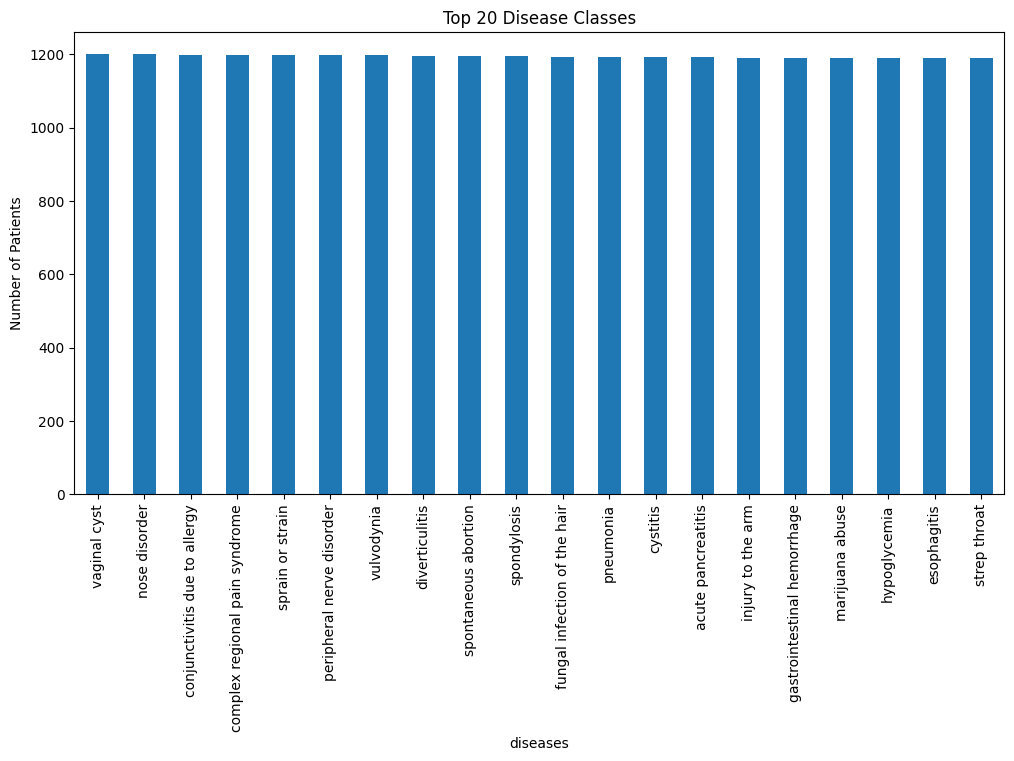

In [46]:
plt.figure(figsize=(12,6))

disease_counts.head(20).plot(kind="bar")

plt.title("Top 20 Disease Classes")

plt.ylabel("Number of Patients")

plt.xticks(rotation=90)

plt.show()

In [47]:
# Class Balance

In [48]:
print(disease_counts.describe())

count     100.000000
mean      942.040000
std       190.100341
min       778.000000
25%       794.750000
50%       804.000000
75%      1184.500000
max      1201.000000
Name: count, dtype: float64


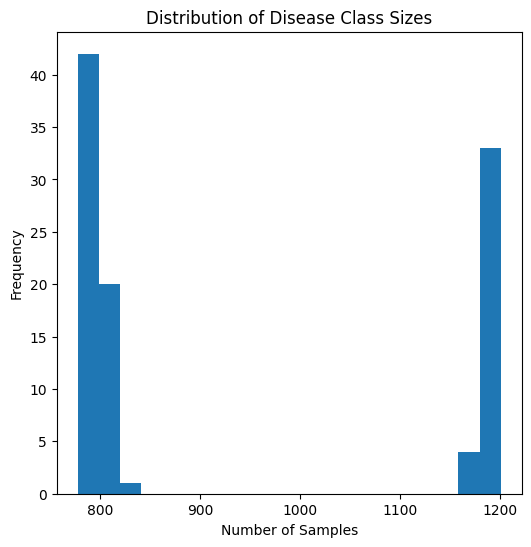

In [49]:
plt.figure(figsize=(6,6))

disease_counts.plot(kind="hist", bins=20)

plt.title("Distribution of Disease Class Sizes")

plt.xlabel("Number of Samples")

plt.show()

In [50]:
# Symptom Frequency

In [51]:
symptom_frequency = df_cleaned.drop("diseases", axis=1).sum().sort_values(ascending=False)

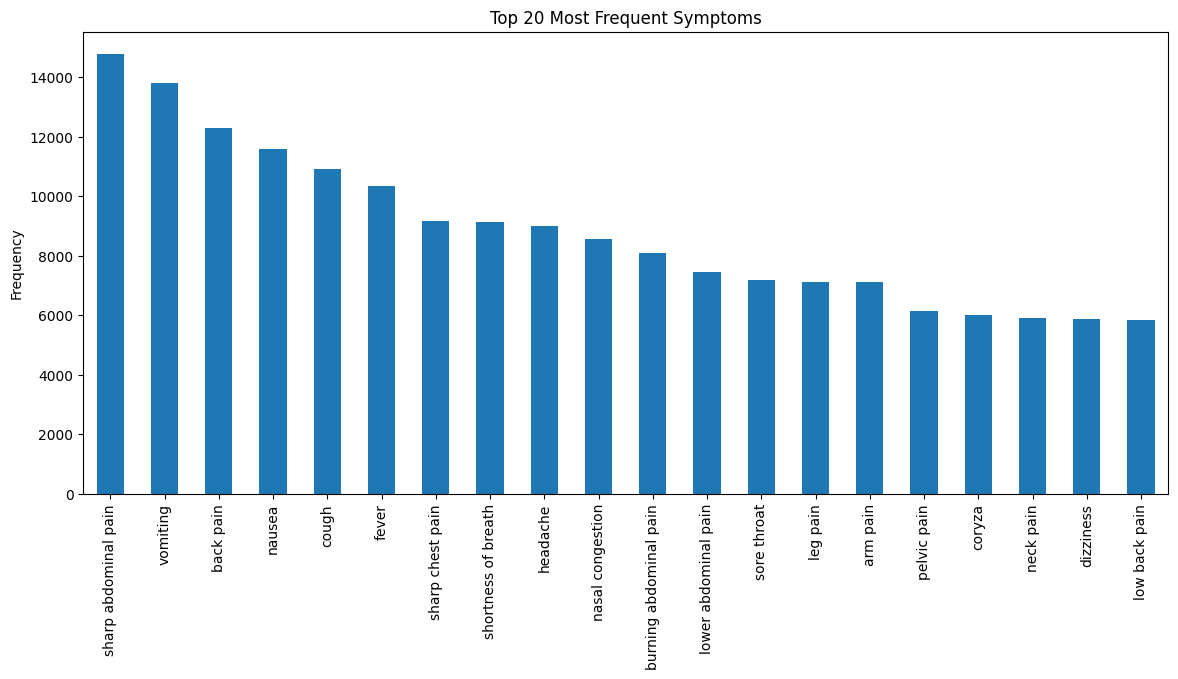

In [52]:
plt.figure(figsize=(14,6))

symptom_frequency.head(20).plot(kind="bar")

plt.title("Top 20 Most Frequent Symptoms")

plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

In [53]:
# Least Common Symptoms

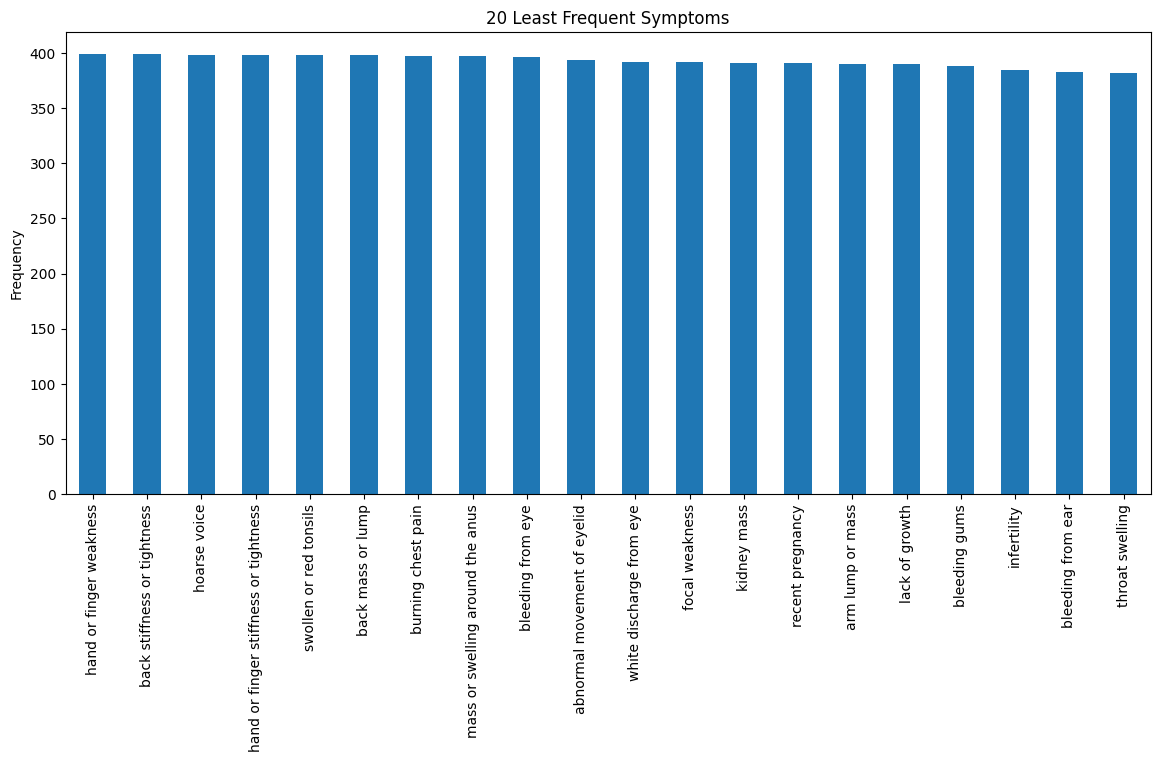

In [54]:
plt.figure(figsize=(14,6))

symptom_frequency.tail(20).plot(kind="bar")

plt.title("20 Least Frequent Symptoms")

plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

In [55]:
# Average Symptoms per Patient

In [56]:
symptom_count = df_cleaned.drop("diseases", axis=1).sum(axis=1)

print(symptom_count.describe())

count    94204.000000
mean         5.823596
std          1.672235
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         12.000000
dtype: float64


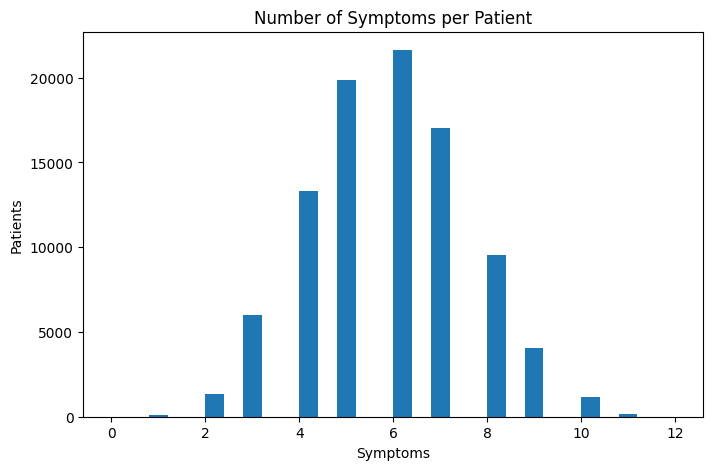

In [57]:
plt.figure(figsize=(8,5))

plt.hist(symptom_count, bins=30)

plt.title("Number of Symptoms per Patient")

plt.xlabel("Symptoms")

plt.ylabel("Patients")

plt.show()

In [58]:
# Correlation Matrix

In [59]:
corr = df_cleaned.drop("diseases", axis=1).corr()

In [60]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(20)

regurgitation                regurgitation.1                 0.637439
pain during intercourse      vaginal redness                 0.576144
mouth ulcer                  bleeding gums                   0.563889
back cramps or spasms        back stiffness or tightness     0.558757
pus draining from ear        bleeding from ear               0.551569
mass on eyelid               eyelid lesion or rash           0.526060
pain in testicles            symptoms of prostate            0.525141
eyelid swelling              eyelid lesion or rash           0.521557
swelling of scrotum          pain in testicles               0.514865
neck swelling                mouth pain                      0.513755
back mass or lump            arm lump or mass                0.513219
pain in testicles            impotence                       0.512706
arm swelling                 elbow swelling                  0.510696
blindness                    bleeding from eye               0.509144
abnormal movement of

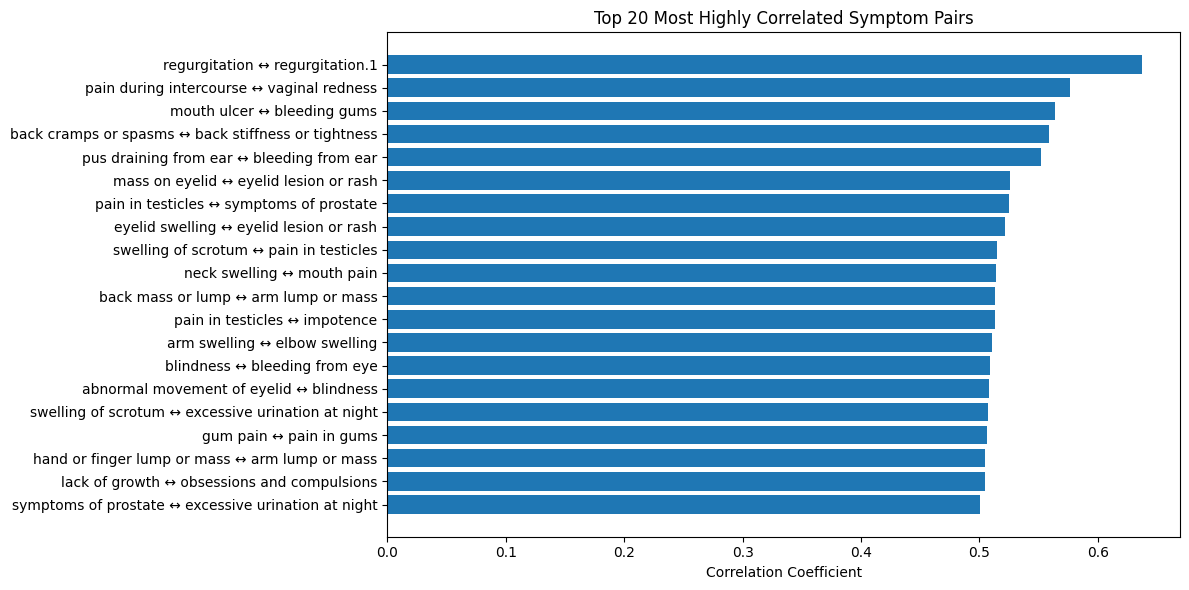

In [61]:
top_corr = corr_pairs.head(20)

plt.figure(figsize=(12,6))

plt.barh(
    [f"{a} ↔ {b}" for a, b in top_corr.index],
    top_corr.values
)

plt.xlabel("Correlation Coefficient")
plt.title("Top 20 Most Highly Correlated Symptom Pairs")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# TASK 4: Feature and Target Preparation

In [62]:
# Encode disease labels

In [63]:
from sklearn.preprocessing import LabelEncoder

# Create Label Encoder
label_encoder = LabelEncoder()

# Encode target variable
df_cleaned["disease_encoded"] = label_encoder.fit_transform(df_cleaned["diseases"])

print("Number of disease classes:", len(label_encoder.classes_))
print("\nFirst 10 disease labels:")

for i, disease in enumerate(label_encoder.classes_[:10]):
    print(f"{i}: {disease}")

Number of disease classes: 100

First 10 disease labels:
0: actinic keratosis
1: acute bronchiolitis
2: acute bronchitis
3: acute bronchospasm
4: acute kidney injury
5: acute pancreatitis
6: acute sinusitis
7: allergy
8: angina
9: anxiety


In [64]:
# Separate Features and Target
X = df_cleaned.drop(
    columns=["diseases", "disease_encoded"]
)

y = df_cleaned["disease_encoded"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)
print("Number of Features  :", X.shape[1])
print("Number of Classes   :", y.nunique())

Feature Matrix Shape: (94204, 230)
Target Vector Shape : (94204,)
Number of Features  : 230
Number of Classes   : 100


In [65]:
# Stratified Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (75363, 230)
Testing Features : (18841, 230)
Training Labels  : (75363,)
Testing Labels   : (18841,)


In [66]:
print("Disease Classes in Full Dataset :", y.nunique())
print("Disease Classes in Training Set :", y_train.nunique())
print("Disease Classes in Testing Set  :", y_test.nunique())

print("\nTraining Proportion:",
      round(len(X_train) / len(X), 4))

print("Testing Proportion :",
      round(len(X_test) / len(X), 4))

Disease Classes in Full Dataset : 100
Disease Classes in Training Set : 100
Disease Classes in Testing Set  : 100

Training Proportion: 0.8
Testing Proportion : 0.2


In [67]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the fitted transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape: (75363, 230)
Scaled Testing Shape : (18841, 230)


# TASK 5 — Model Development

In [68]:
# Model Development Libraries

In [69]:
import time
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [70]:
# Define Baseline Classification Models

In [71]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=100,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=2
    ),

    "Artificial Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        random_state=42
    )
}

print("Baseline models defined successfully.")

Baseline models defined successfully.


In [72]:
# Train and Evaluate Baseline Models

In [73]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Select appropriate feature representation
    if name in ["Logistic Regression", "Artificial Neural Network"]:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test

    # Model Training
    start_train = time.time()

    model.fit(
        X_train_model,
        y_train
    )

    training_time = (
        time.time() - start_train
    )

    # Prediction
    start_pred = time.time()

    y_pred = model.predict(
        X_test_model
    )

    prediction_time = (
        time.time() - start_pred
    )

    # Evaluation Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    })

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print()

Training Logistic Regression...
Accuracy  : 0.8856
Precision : 0.8913
Recall    : 0.8856
F1 Score  : 0.8866

Training Decision Tree...
Accuracy  : 0.8421
Precision : 0.8429
Recall    : 0.8421
F1 Score  : 0.8419

Training Random Forest...
Accuracy  : 0.8575
Precision : 0.8586
Recall    : 0.8575
F1 Score  : 0.8578

Training XGBoost...
Accuracy  : 0.8611
Precision : 0.8626
Recall    : 0.8611
F1 Score  : 0.8615

Training Artificial Neural Network...
Accuracy  : 0.8591
Precision : 0.8604
Recall    : 0.8591
F1 Score  : 0.8590



In [74]:
# Baseline Performance Comparison

In [75]:
baseline_results = pd.DataFrame(
    results
)

baseline_results = (
    baseline_results
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Baseline Model Performance")

display(
    baseline_results.round(4)
)

Baseline Model Performance


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8856,0.8913,0.8856,0.8866,52.8389,0.0424
1,XGBoost,0.8611,0.8626,0.8611,0.8615,363.1015,4.3000
2,Artificial Neural Network,0.8591,0.8604,0.8591,0.8590,380.4775,0.1074
3,Random Forest,0.8575,0.8586,0.8575,0.8578,17.2072,1.6705
4,Decision Tree,0.8421,0.8429,0.8421,0.8419,3.5670,0.0263


In [76]:
# Leakage-Safe Cross-Validation Setup

In [77]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=1
    )
}

print("Leakage-safe CV models prepared.")

Leakage-safe CV models prepared.


In [78]:
# Run 5-Fold CV 

In [79]:
cv_results_list = []

for name, model in cv_models.items():

    print(f"\nRun 5-Fold CV for {name}...")

    scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=2,
        error_score="raise"
    )

    cv_results_list.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

cv_results_part1 = pd.DataFrame(cv_results_list)

display(
    cv_results_part1
    .sort_values("Mean Accuracy", ascending=False)
    .reset_index(drop=True)
    .round(4)
)


Run 5-Fold CV for Logistic Regression...

Run 5-Fold CV for Decision Tree...

Run 5-Fold CV for Random Forest...


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.8894,0.8892,0.8904,0.8860,0.8861,0.8882,0.0018
1,Random Forest,0.8651,0.8649,0.8689,0.8616,0.8618,0.8644,0.0027
2,Decision Tree,0.8479,0.8421,0.8471,0.8424,0.8443,0.8448,0.0024


In [80]:
# XGBoost Cross-Validation

In [81]:
xgb_cv_model = XGBClassifier(
    objective="multi:softprob",
    num_class=100,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=2
)


xgb_cv_scores = cross_val_score(
    estimator=xgb_cv_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    error_score="raise"
)

print("\nXGBoost CV Scores:")
print(np.round(xgb_cv_scores, 4))

print(
    "Mean CV Accuracy:",
    round(xgb_cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(xgb_cv_scores.std(), 4)
)


XGBoost CV Scores:
[0.8761 0.8738 0.8798 0.8722 0.8722]
Mean CV Accuracy: 0.8748
CV Standard Deviation: 0.0029


In [82]:
# ANN Leakage-Safe 3-Fold Cross-Validation

In [83]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

ann_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

ann_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=150,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

print("Running 3-Fold Cross-Validation for ANN...")

ann_cv_scores = cross_val_score(
    estimator=ann_cv_model,
    X=X_train,
    y=y_train,
    cv=ann_cv,
    scoring="accuracy",
    n_jobs=1,
    error_score="raise"
)

print("\nANN 3-Fold CV Scores:")
print(np.round(ann_cv_scores, 4))

print(
    "Mean CV Accuracy:",
    round(ann_cv_scores.mean(), 4)
)

print(
    "CV Standard Deviation:",
    round(ann_cv_scores.std(), 4)
)

Running 3-Fold Cross-Validation for ANN...

ANN 3-Fold CV Scores:
[0.8875 0.8839 0.8813]
Mean CV Accuracy: 0.8842
CV Standard Deviation: 0.0026


In [84]:
#Combined Cross-Validation Summary

In [85]:
combined_cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Artificial Neural Network",
        "XGBoost",
        "Random Forest",
        "Decision Tree"
    ],

    "CV Folds": [
        5,
        3,
        5,
        5,
        5
    ],

    "Mean Accuracy": [
        cv_results_part1.loc[
            cv_results_part1["Model"] == "Logistic Regression",
            "Mean Accuracy"
        ].iloc[0],

        ann_cv_scores.mean(),

        xgb_cv_scores.mean(),

        cv_results_part1.loc[
            cv_results_part1["Model"] == "Random Forest",
            "Mean Accuracy"
        ].iloc[0],

        cv_results_part1.loc[
            cv_results_part1["Model"] == "Decision Tree",
            "Mean Accuracy"
        ].iloc[0]
    ],

    "Standard Deviation": [
        cv_results_part1.loc[
            cv_results_part1["Model"] == "Logistic Regression",
            "Standard Deviation"
        ].iloc[0],

        ann_cv_scores.std(),

        xgb_cv_scores.std(),

        cv_results_part1.loc[
            cv_results_part1["Model"] == "Random Forest",
            "Standard Deviation"
        ].iloc[0],

        cv_results_part1.loc[
            cv_results_part1["Model"] == "Decision Tree",
            "Standard Deviation"
        ].iloc[0]
    ],

    "CV Notes": [
        "5-fold, scaling inside pipeline",
        "3-fold, scaling inside pipeline, early stopping",
        "5-fold, reduced 100-estimator configuration",
        "5-fold",
        "5-fold"
    ]
})

combined_cv_results = (
    combined_cv_results
    .sort_values(
        "Mean Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final Cross-Validation Summary")

display(
    combined_cv_results.round(4)
)

Final Cross-Validation Summary


,Model,CV Folds,Mean Accuracy,Standard Deviation,CV Notes
0,Logistic Regression,5,0.8882,0.0018,"5-fold, scaling inside pipeline"
1,Artificial Neural Network,3,0.8842,0.0026,"3-fold, scaling inside pipeline, early stopping"
2,XGBoost,5,0.8748,0.0029,"5-fold, reduced 100-estimator configuration"
3,Random Forest,5,0.8644,0.0027,5-fold
4,Decision Tree,5,0.8448,0.0024,5-fold


# Task 6: Hyperparameter Tuning

In [86]:
# Hyperparameter Tuning – Logistic Regression

In [87]:
from sklearn.model_selection import RandomizedSearchCV
print("Hyperparameter Tuning: Logistic Regression")

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

param_dist = {
    "model__C": np.logspace(-3, 3, 8)
}

random_lr = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=2,
    verbose=1
)

random_lr.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_lr.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random_lr.best_score_, 4))

Hyperparameter Tuning: Logistic Regression
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters:
{'model__C': np.float64(0.0517947467923121)}

Best Cross Validation Accuracy:
0.8885


In [88]:
# Final Tuned Logistic Regression
lr_final = random_lr.best_estimator_

y_pred_lr = lr_final.predict(X_test)

print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred_lr),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred_lr,
            average="weighted"
        ),
        4
    )
)

Accuracy: 0.8875
F1 Score: 0.8887


In [ ]:
# Hyperparameter Tuning – XGBoost model

In [89]:
print("Hyperparameter Tuning: XGBoost")

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=2
)

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_xgb.fit(X_train, y_train)

print("\nBest Parameters:")
print(random_xgb.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random_xgb.best_score_, 4))

Hyperparameter Tuning: XGBoost
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=200; total time= 4.1min
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=200; total time= 3.9min
[CV] END ..learning_rate=0.05, max_depth=8, n_estimators=200; total time= 4.0min
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=150; total time= 3.0min
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=150; total time= 2.9min
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=150; total time= 3.0min
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=100; total time= 1.7min
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=100; total time= 1.8min
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=100; total time= 1.7min
[CV] END ...learning_rate=0.2, max_depth=6, n_estimators=100; total time= 2.2min
[CV] END ...learning_rate=0.2, max_depth=6, n_estimators=100; total time= 2.3min
[CV] END ...learni

In [90]:
# Final tuned XGBoost
xgb_final = random_xgb.best_estimator_

y_pred_xgb = xgb_final.predict(X_test)

print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred_xgb),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred_xgb,
            average="weighted"
        ),
        4
    )
)

Accuracy: 0.8843
F1 Score: 0.8861


In [92]:
# Hyperparameter Tuning – Artificial Neural Network

In [91]:
print("Hyperparameter Tuning: ANN")

ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        max_iter=150,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    ))
])

ann_param_dist = {
    "model__hidden_layer_sizes": [
        (64,),
        (100,),
        (128, 64)
    ],
    "model__alpha": [
        0.0001,
        0.001
    ],
    "model__learning_rate_init": [
        0.001,
        0.01
    ]
}

random_ann = RandomizedSearchCV(
    estimator=ann_pipeline,
    param_distributions=ann_param_dist,
    n_iter=4,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=0
)

random_ann.fit(
    X_train,
    y_train
)

print("\nBest ANN Parameters:")
print(random_ann.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random_ann.best_score_, 4))

Hyperparameter Tuning: ANN

Best ANN Parameters:
{'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (64,), 'model__alpha': 0.0001}

Best Cross Validation Accuracy:
0.8857


In [93]:
# Final Tuned ANN
ann_final = random_ann.best_estimator_

y_pred_ann = ann_final.predict(X_test)

ann_accuracy = accuracy_score(
    y_test,
    y_pred_ann
)

ann_f1 = f1_score(
    y_test,
    y_pred_ann,
    average="weighted"
)

print("Accuracy:", round(ann_accuracy, 4))
print("F1 Score:", round(ann_f1, 4))

Accuracy: 0.8841
F1 Score: 0.8847


In [94]:
# Final Hyperparameter Tuning Comparison

In [95]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Artificial Neural Network"
    ],
    
    "Baseline Accuracy": [
        0.8856,
        0.8611,
        0.8591
    ],
    
    "Tuned CV Accuracy": [
        random_lr.best_score_,
        random_xgb.best_score_,
        random_ann.best_score_
    ],
    
    "Tuned Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_ann)
    ],
    
    "Tuned F1 Score": [
        f1_score(
            y_test,
            y_pred_lr,
            average="weighted"
        ),
        f1_score(
            y_test,
            y_pred_xgb,
            average="weighted"
        ),
        f1_score(
            y_test,
            y_pred_ann,
            average="weighted"
        )
    ]
})

tuning_comparison["Accuracy Improvement"] = (
    tuning_comparison["Tuned Test Accuracy"]
    - tuning_comparison["Baseline Accuracy"]
)

tuning_comparison = (
    tuning_comparison
    .sort_values(
        "Tuned Test Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final Hyperparameter Tuning Comparison")

display(
    tuning_comparison.round(4)
)

Final Hyperparameter Tuning Comparison


,Model,Baseline Accuracy,Tuned CV Accuracy,Tuned Test Accuracy,Tuned F1 Score,Accuracy Improvement
0,Logistic Regression,0.8856,0.8885,0.8875,0.8887,0.0019
1,XGBoost,0.8611,0.8831,0.8843,0.8861,0.0232
2,Artificial Neural Network,0.8591,0.8857,0.8841,0.8847,0.0250


# TASK 7: Final Model Evaluation and Error Analysis

In [96]:
# Final Model Predictions

In [98]:
# Tuned Logistic Regression
y_pred_lr_final = lr_final.predict(X_test)

# Tuned XGBoost
y_pred_xgb_final = xgb_final.predict(X_test)

# Tuned ANN
y_pred_ann_final = ann_final.predict(X_test)

# Baseline Random Forest and Decision Tree
y_pred_rf_final = trained_models["Random Forest"].predict(X_test)

y_pred_dt_final = trained_models["Decision Tree"].predict(X_test)

In [99]:
# Final Model Performance Comparison

In [100]:
final_predictions = {
    "Logistic Regression (Tuned)": y_pred_lr_final,
    "XGBoost (Tuned)": y_pred_xgb_final,
    "Artificial Neural Network (Tuned)": y_pred_ann_final,
    "Random Forest": y_pred_rf_final,
    "Decision Tree": y_pred_dt_final
}

final_results_list = []

for model_name, predictions in final_predictions.items():

    final_results_list.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })


final_results = pd.DataFrame(
    final_results_list
)

final_results = (
    final_results
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final Model Performance Comparison")

display(
    final_results.round(4)
)

Final Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Tuned),0.8875,0.8936,0.8875,0.8887
1,XGBoost (Tuned),0.8843,0.8910,0.8843,0.8861
2,Artificial Neural Network (Tuned),0.8841,0.8923,0.8841,0.8847
3,Random Forest,0.8575,0.8586,0.8575,0.8578
4,Decision Tree,0.8421,0.8429,0.8421,0.8419


In [103]:
# Tuned Logistic Regression Report
from sklearn.metrics import classification_report

In [104]:
lr_report = classification_report(
    y_test,
    y_pred_lr_final,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

lr_report_df = pd.DataFrame(
    lr_report
).transpose()

print(
    "Final Tuned Logistic Regression "
    "Classification Report"
)

display(
    lr_report_df.round(4)
)

Final Tuned Logistic Regression Classification Report


,precision,recall,f1-score,support
actinic keratosis,0.9444,0.7484,0.8351,159.0000
acute bronchiolitis,0.9638,0.8987,0.9301,237.0000
acute bronchitis,0.8691,0.7004,0.7757,237.0000
acute bronchospasm,0.6526,0.7750,0.7086,160.0000
acute kidney injury,0.9742,0.9679,0.9711,156.0000
...,...,...,...,...
vaginitis,0.9740,0.9259,0.9494,162.0000
vulvodynia,0.9267,0.8958,0.9110,240.0000
accuracy,0.8875,0.8875,0.8875,0.8875
macro avg,0.8890,0.8900,0.8876,18841.0000


In [107]:
# Tuned XGBoost Report
xgb_report = classification_report(
    y_test,
    y_pred_xgb_final,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

xgb_report_df = pd.DataFrame(
    xgb_report
).transpose()

print(
    "Final Tuned XGBoost Classification Report"
)

display(
    xgb_report_df.round(4)
)

Final Tuned XGBoost Classification Report


,precision,recall,f1-score,support
actinic keratosis,0.9237,0.7610,0.8345,159.0000
acute bronchiolitis,0.9550,0.8945,0.9237,237.0000
acute bronchitis,0.8000,0.7089,0.7517,237.0000
acute bronchospasm,0.6318,0.7938,0.7036,160.0000
acute kidney injury,0.9744,0.9744,0.9744,156.0000
...,...,...,...,...
vaginitis,0.9866,0.9074,0.9453,162.0000
vulvodynia,0.9004,0.9042,0.9023,240.0000
accuracy,0.8843,0.8843,0.8843,0.8843
macro avg,0.8879,0.8856,0.8851,18841.0000


In [108]:
# Tuned ANN Report
ann_report = classification_report(
    y_test,
    y_pred_ann_final,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

ann_report_df = pd.DataFrame(
    ann_report
).transpose()

print(
    "Final Tuned ANN Classification Report"
)

display(
    ann_report_df.round(4)
)

Final Tuned ANN Classification Report


,precision,recall,f1-score,support
actinic keratosis,0.8269,0.8113,0.8190,159.0000
acute bronchiolitis,0.9860,0.8945,0.9381,237.0000
acute bronchitis,0.7900,0.7300,0.7588,237.0000
acute bronchospasm,0.6095,0.8000,0.6919,160.0000
acute kidney injury,0.9444,0.9808,0.9623,156.0000
...,...,...,...,...
vaginitis,0.9620,0.9383,0.9500,162.0000
vulvodynia,0.9177,0.8833,0.9002,240.0000
accuracy,0.8841,0.8841,0.8841,0.8841
macro avg,0.8886,0.8855,0.8834,18841.0000


In [109]:
# Error Analysis
# Misclassification Pair Function

In [110]:
from sklearn.metrics import confusion_matrix

def extract_misclassification_pairs(
    y_true,
    y_pred,
    class_names
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Remove correct classifications
    np.fill_diagonal(cm, 0)

    error_pairs = []

    for true_idx in range(cm.shape[0]):

        for pred_idx in range(cm.shape[1]):

            count = cm[
                true_idx,
                pred_idx
            ]

            if count > 0:

                error_pairs.append({
                    "True Disease":
                        class_names[true_idx],

                    "Predicted Disease":
                        class_names[pred_idx],

                    "Misclassification Count":
                        count
                })

    error_df = pd.DataFrame(
        error_pairs
    )

    return (
        error_df
        .sort_values(
            "Misclassification Count",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [111]:
# Logistic Regression Errors
error_pairs_lr = extract_misclassification_pairs(
    y_test,
    y_pred_lr_final,
    label_encoder.classes_
)

print(
    "Top 15 Tuned Logistic Regression "
    "Misclassification Pairs"
)

display(
    error_pairs_lr.head(15)
)

Top 15 Tuned Logistic Regression Misclassification Pairs


,True Disease,Predicted Disease,Misclassification Count
0,infectious gastroenteritis,noninfectious gastroenteritis,67
1,cholecystitis,gallstone,46
2,schizophrenia,personality disorder,43
3,marijuana abuse,personality disorder,42
4,cystitis,temporary or benign blood in urine,42
5,spinal stenosis,degenerative disc disease,40
6,noninfectious gastroenteritis,infectious gastroenteritis,39
7,acute bronchitis,chronic obstructive pulmonary disease (copd),37
8,skin polyp,skin pigmentation disorder,35
9,pneumonia,acute bronchospasm,32


In [112]:
# XGBoost Errors
error_pairs_xgb = extract_misclassification_pairs(
    y_test,
    y_pred_xgb_final,
    label_encoder.classes_
)

print(
    "Top 15 Tuned XGBoost "
    "Misclassification Pairs"
)

display(
    error_pairs_xgb.head(15)
)

Top 15 Tuned XGBoost Misclassification Pairs


,True Disease,Predicted Disease,Misclassification Count
0,infectious gastroenteritis,noninfectious gastroenteritis,72
1,noninfectious gastroenteritis,infectious gastroenteritis,54
2,cystitis,temporary or benign blood in urine,52
3,cholecystitis,gallstone,51
4,marijuana abuse,personality disorder,40
5,schizophrenia,personality disorder,40
6,skin polyp,skin pigmentation disorder,37
7,acute bronchitis,chronic obstructive pulmonary disease (copd),37
8,spinal stenosis,degenerative disc disease,36
9,pneumonia,acute bronchospasm,33


In [113]:
# ANN Errors
error_pairs_ann = extract_misclassification_pairs(
    y_test,
    y_pred_ann_final,
    label_encoder.classes_
)

print(
    "Top 15 Tuned ANN "
    "Misclassification Pairs"
)

display(
    error_pairs_ann.head(15)
)

Top 15 Tuned ANN Misclassification Pairs


,True Disease,Predicted Disease,Misclassification Count
0,infectious gastroenteritis,noninfectious gastroenteritis,73
1,schizophrenia,personality disorder,65
2,cystitis,temporary or benign blood in urine,61
3,gallstone,cholecystitis,56
4,skin polyp,skin pigmentation disorder,50
5,marijuana abuse,personality disorder,46
6,spinal stenosis,degenerative disc disease,38
7,pneumonia,acute bronchospasm,36
8,spondylosis,degenerative disc disease,29
9,spontaneous abortion,vaginal cyst,29


In [114]:
# Common Misclassification Patterns

lr_top = error_pairs_lr.head(15).copy()
xgb_top = error_pairs_xgb.head(15).copy()
ann_top = error_pairs_ann.head(15).copy()


for error_df in [
    lr_top,
    xgb_top,
    ann_top
]:

    error_df["Pair"] = (
        error_df["True Disease"]
        + " → "
        + error_df["Predicted Disease"]
    )


all_pairs = pd.concat([
    lr_top[
        ["Pair"]
    ].assign(
        Model="Logistic Regression"
    ),

    xgb_top[
        ["Pair"]
    ].assign(
        Model="XGBoost"
    ),

    ann_top[
        ["Pair"]
    ].assign(
        Model="ANN"
    )
])


common_errors = (
    all_pairs
    .groupby("Pair")
    .agg(
        Number_of_Models=(
            "Model",
            "nunique"
        ),

        Models=(
            "Model",
            lambda x:
            ", ".join(sorted(set(x)))
        )
    )
    .reset_index()
)


common_errors = (
    common_errors[
        common_errors[
            "Number_of_Models"
        ] >= 2
    ]
    .sort_values(
        "Number_of_Models",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Common Misclassification Patterns Across Models"
)

display(
    common_errors
)

Common Misclassification Patterns Across Models


,Pair,Number_of_Models,Models
0,acute bronchitis → chronic obstructive pulmona...,3,"ANN, Logistic Regression, XGBoost"
1,infectious gastroenteritis → noninfectious gas...,3,"ANN, Logistic Regression, XGBoost"
2,cystitis → temporary or benign blood in urine,3,"ANN, Logistic Regression, XGBoost"
3,marijuana abuse → personality disorder,3,"ANN, Logistic Regression, XGBoost"
4,noninfectious gastroenteritis → infectious gas...,3,"ANN, Logistic Regression, XGBoost"
5,schizophrenia → personality disorder,3,"ANN, Logistic Regression, XGBoost"
6,pneumonia → acute bronchospasm,3,"ANN, Logistic Regression, XGBoost"
7,spondylosis → degenerative disc disease,3,"ANN, Logistic Regression, XGBoost"
8,skin polyp → skin pigmentation disorder,3,"ANN, Logistic Regression, XGBoost"
9,spinal stenosis → degenerative disc disease,3,"ANN, Logistic Regression, XGBoost"


In [115]:
# Task 7 Final Summary
task7_summary = pd.DataFrame({
    "Metric": [
        "Best Final Model",
        "Best Accuracy",
        "Best Weighted F1",
        "Number of Common Error Pairs Across 3 Models",
        "Common Error Pairs Shared by All 3 Models"
    ],
    "Value": [
        final_results.iloc[0]["Model"],
        final_results.iloc[0]["Accuracy"],
        final_results.iloc[0]["F1 Score"],
        len(common_errors),
        (common_errors["Number_of_Models"] == 3).sum()
    ]
})

print("Task 7: Final Evaluation Summary")
display(task7_summary)

Task 7: Final Evaluation Summary


,Metric,Value
0,Best Final Model,Logistic Regression (Tuned)
1,Best Accuracy,0.887479
2,Best Weighted F1,0.888652
3,Number of Common Error Pairs Across 3 Models,15
4,Common Error Pairs Shared by All 3 Models,10


# TASK 8: Explainable Artificial Intelligence (XAI)

In [214]:
import shap
import lime

In [215]:
## SHAP Explainability

In [216]:
# Class-Representative XAI Sample
xai_index_df = pd.DataFrame({
    "row_position": np.arange(len(y_test)),
    "class_label": y_test.to_numpy()
})

xai_sample_df = (
    xai_index_df
    .groupby("class_label", group_keys=False)
    .sample(n=1, random_state=42)
    .sort_values("class_label")
    .reset_index(drop=True)
)

xai_indices = xai_sample_df[
    "row_position"
].to_numpy()

# IMPORTANT:
# XGBoost was trained on unscaled binary features
X_xai_sample = X_test.iloc[
    xai_indices
].copy()

y_xai_sample = y_test.iloc[
    xai_indices
].copy()

print("XAI Sample Shape:", X_xai_sample.shape)
print(
    "Disease Classes Represented:",
    y_xai_sample.nunique()
)
print(
    "Total Disease Classes:",
    len(label_encoder.classes_)
)

XAI Sample Shape: (100, 230)
Disease Classes Represented: 100
Total Disease Classes: 100


In [217]:
# SHAP TreeExplainer
shap_explainer = shap.TreeExplainer(
    xgb_final
)

shap_values = shap_explainer(
    X_xai_sample
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

SHAP values shape: (100, 230, 100)


In [218]:
# Predicted-Class SHAP Values
xai_pred = xgb_final.predict(
    X_xai_sample
)

shap_predicted_class_values = np.array([
    shap_values.values[
        i,
        :,
        int(xai_pred[i])
    ]
    for i in range(len(X_xai_sample))
])

print(
    "Predicted-class SHAP shape:",
    shap_predicted_class_values.shape
)

Predicted-class SHAP shape: (100, 230)


In [219]:
feature_names = X.columns.tolist()

In [220]:
# Class-Balanced Global SHAP Importance
# Mean absolute SHAP value across
# the 100 class-representative XAI cases
mean_abs_shap = np.abs(
    shap_predicted_class_values
).mean(axis=0)

# Create feature importance table
shap_importance_df = pd.DataFrame({
    "Symptom": feature_names,
    "Mean Absolute SHAP": mean_abs_shap
})

# Rank features
shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df["SHAP Rank"] = (
    np.arange(
        1,
        len(shap_importance_df) + 1
    )
)

print(
    "Top 20 Symptoms by "
    "Class-Balanced Global SHAP Importance"
)

display(
    shap_importance_df
    .head(20)
    .round(6)
)

Top 20 Symptoms by Class-Balanced Global SHAP Importance


,Symptom,Mean Absolute SHAP,SHAP Rank
0,headache,0.083283,1
1,upper abdominal pain,0.082487,2
2,lower body pain,0.079901,3
3,sharp chest pain,0.079793,4
4,chills,0.077999,5
5,vomiting,0.076250,6
6,swollen eye,0.074327,7
7,weakness,0.070648,8
8,heartburn,0.069106,9
9,chest tightness,0.067310,10


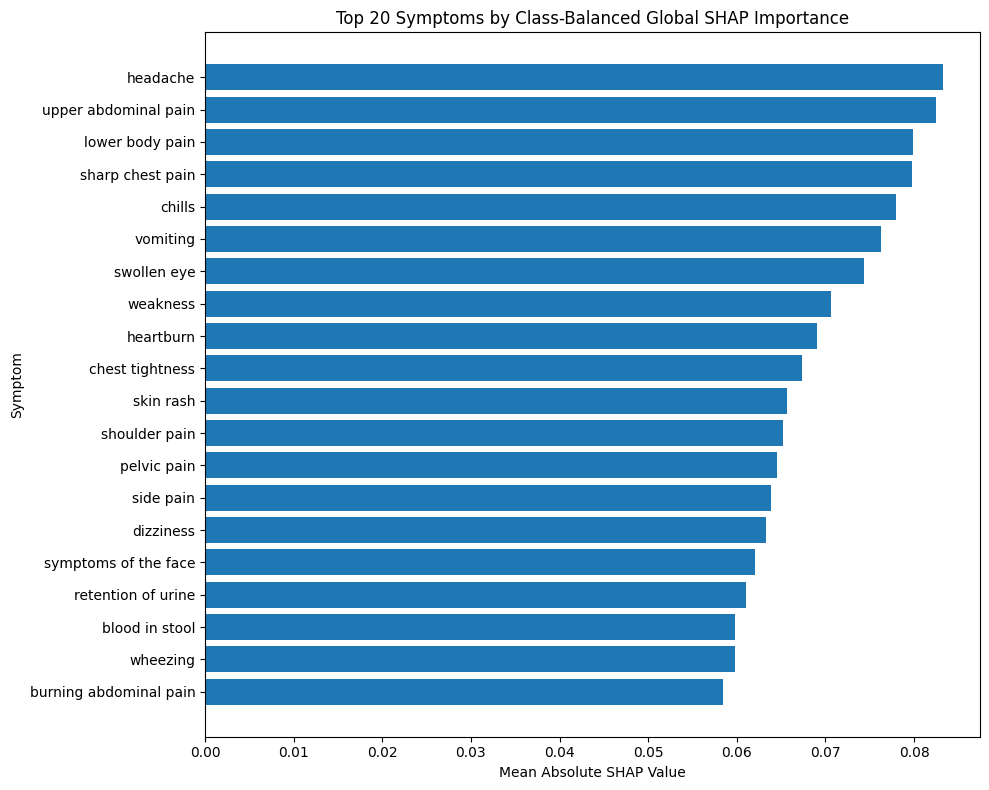

In [221]:
# Global SHAP Importance Plot
top20_shap = (
    shap_importance_df
    .head(20)
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_shap["Symptom"],
    top20_shap["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Symptom")

plt.title(
    "Top 20 Symptoms by "
    "Class-Balanced Global SHAP Importance"
)

plt.tight_layout()
plt.show()

In [222]:
# Class-Balanced Global LIME Importance
global_lime_records = []

for i in range(len(X_xai_sample)):

    predicted_class = int(xai_pred[i])

    lime_exp_i = lime_explainer.explain_instance(
        data_row=X_xai_sample.iloc[i].to_numpy(),
        predict_fn=xgb_final.predict_proba,
        labels=[predicted_class],
        num_features=230,
        num_samples=2000
    )

    lime_list_i = lime_exp_i.as_list(
        label=predicted_class
    )

    lime_df_i = pd.DataFrame(
        lime_list_i,
        columns=["Symptom", "LIME Weight"]
    )

    # Clean =0 / =1 suffix
    lime_df_i["Symptom"] = (
        lime_df_i["Symptom"]
        .str.replace(r"=[01]$", "", regex=True)
    )

    lime_df_i["Absolute LIME"] = (
        lime_df_i["LIME Weight"].abs()
    )

    lime_df_i["Case"] = i + 1

    global_lime_records.append(
        lime_df_i[
            ["Case", "Symptom", "Absolute LIME"]
        ]
    )

global_lime_df = pd.concat(
    global_lime_records,
    ignore_index=True
)

lime_importance_df = (
    global_lime_df
    .groupby("Symptom")["Absolute LIME"]
    .mean()
    .reset_index()
)

lime_importance_df = (
    lime_importance_df
    .sort_values(
        "Absolute LIME",
        ascending=False
    )
    .reset_index(drop=True)
)

lime_importance_df["LIME Rank"] = (
    np.arange(
        1,
        len(lime_importance_df) + 1
    )
)

print(
    "Top 20 Symptoms by "
    "Class-Balanced Global LIME Importance"
)

display(
    lime_importance_df
    .head(20)
    .round(6)
)

Top 20 Symptoms by Class-Balanced Global LIME Importance


,Symptom,Absolute LIME,LIME Rank
0,symptoms of the face,0.015490,1
1,hoarse voice,0.014448,2
2,hysterical behavior,0.014108,3
3,symptoms of the scrotum and testes,0.013925,4
4,back cramps or spasms,0.013230,5
5,vaginal itching,0.013212,6
6,mouth ulcer,0.013171,7
7,hemoptysis,0.013155,8
8,hot flashes,0.012761,9
9,breathing fast,0.012628,10


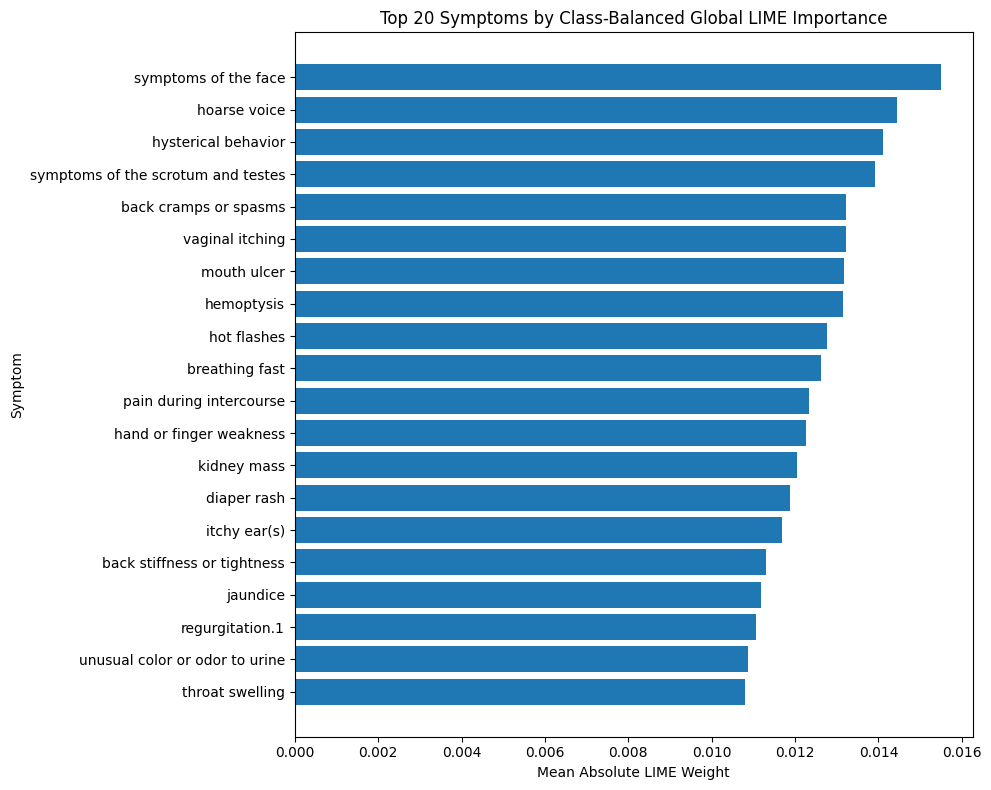

In [223]:
# Global LIME Importance Plot
top20_lime = (
    lime_importance_df
    .head(20)
    .sort_values(
        "Absolute LIME",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_lime["Symptom"],
    top20_lime["Absolute LIME"]
)

plt.xlabel("Mean Absolute LIME Weight")
plt.ylabel("Symptom")

plt.title(
    "Top 20 Symptoms by "
    "Class-Balanced Global LIME Importance"
)

plt.tight_layout()
plt.show()

In [224]:
# Global SHAP-LIME Top-20 Comparison
global_shap_top20 = set(
    shap_importance_df
    .head(20)["Symptom"]
)

global_lime_top20 = set(
    lime_importance_df
    .head(20)["Symptom"]
)

global_common_features = (
    global_shap_top20.intersection(
        global_lime_top20
    )
)

global_overlap = (
    len(global_common_features) / 20
)

print(
    "Common Global Top-20 Features:",
    len(global_common_features)
)

print(
    "Global Top-20 SHAP-LIME Overlap:",
    round(global_overlap, 4)
)

print("\nCommon Global Features:")

for feature in sorted(global_common_features):
    print("-", feature)

Common Global Top-20 Features: 1
Global Top-20 SHAP-LIME Overlap: 0.05

Common Global Features:
- symptoms of the face


In [225]:
# Local SHAP explanation

In [226]:
instance_idx = 0

true_class = int(
    y_xai_sample.iloc[instance_idx]
)

predicted_class = int(
    xai_pred[instance_idx]
)

true_disease = (
    label_encoder.inverse_transform(
        [true_class]
    )[0]
)

predicted_disease = (
    label_encoder.inverse_transform(
        [predicted_class]
    )[0]
)

local_shap_values = (
    shap_predicted_class_values[
        instance_idx
    ]
)

local_shap_df = pd.DataFrame({
    "Symptom": feature_names,
    "SHAP Value": local_shap_values,
    "Absolute SHAP":
        np.abs(local_shap_values)
})

local_shap_df = (
    local_shap_df
    .sort_values(
        "Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("True Disease      :", true_disease)
print("Predicted Disease :", predicted_disease)

print(
    "\nTop 10 SHAP Features "
    "for this Prediction:"
)

display(
    local_shap_df[
        [
            "Symptom",
            "SHAP Value",
            "Absolute SHAP"
        ]
    ]
    .head(10)
    .round(6)
)

True Disease      : actinic keratosis
Predicted Disease : actinic keratosis

Top 10 SHAP Features for this Prediction:


,Symptom,SHAP Value,Absolute SHAP
0,symptoms of the face,6.145321,6.145321
1,skin irritation,0.438821,0.438821
2,skin lesion,0.217666,0.217666
3,itching of skin,0.154505,0.154505
4,abnormal appearing skin,0.118783,0.118783
5,skin moles,-0.062178,0.062178
6,skin growth,-0.060133,0.060133
7,skin rash,-0.059059,0.059059
8,acne or pimples,0.050749,0.050749
9,irregular appearing scalp,-0.044791,0.044791


In [227]:
# LIME Explainer for Binary Symptoms

from lime.lime_tabular import LimeTabularExplainer

categorical_feature_indices = list(
    range(len(feature_names))
)

lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=feature_names,
    class_names=label_encoder.classes_.tolist(),
    mode="classification",
    categorical_features=categorical_feature_indices,
    discretize_continuous=False,
    random_state=42
)

print("Number of Features:", len(feature_names))
print("Number of Disease Classes:", len(label_encoder.classes_))
print("Binary/Categorical Features:",
      len(categorical_feature_indices))

Number of Features: 230
Number of Disease Classes: 100
Binary/Categorical Features: 230


In [228]:
# Local LIME Explanation
instance_idx = 0

predicted_class = int(
    xai_pred[instance_idx]
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_xai_sample.iloc[
        instance_idx
    ].to_numpy(),

    predict_fn=xgb_final.predict_proba,

    labels=[predicted_class],

    num_features=10,
    num_samples=3000
)

lime_local = lime_exp.as_list(
    label=predicted_class
)

lime_local_df = pd.DataFrame(
    lime_local,
    columns=[
        "Symptom",
        "LIME Weight"
    ]
)

lime_local_df["Absolute LIME"] = (
    lime_local_df["LIME Weight"].abs()
)

print(
    "Predicted Disease:",
    label_encoder.inverse_transform(
        [predicted_class]
    )[0]
)

print(
    "\nTop 10 LIME Features for this Prediction:"
)

display(
    lime_local_df[
        [
            "Symptom",
            "LIME Weight",
            "Absolute LIME"
        ]
    ].round(6)
)

Predicted Disease: actinic keratosis

Top 10 LIME Features for this Prediction:


,Symptom,LIME Weight,Absolute LIME
0,symptoms of the face=1,0.826191,0.826191
1,skin moles=0,-0.022769,0.022769
2,itchy ear(s)=0,0.015167,0.015167
3,skin growth=0,-0.014795,0.014795
4,skin irritation=1,0.010369,0.010369
5,"skin dryness, peeling, scaliness, or roughness=0",-0.008034,0.008034
6,irregular appearing scalp=0,-0.006150,0.006150
7,neck mass=0,0.005622,0.005622
8,hand or finger weakness=0,0.004270,0.004270
9,hysterical behavior=0,0.003895,0.003895


In [229]:
lime_local_df["Symptom Clean"] = (
    lime_local_df["Symptom"]
    .str.replace(r"=[01]$", "", regex=True)
)

print("Cleaned LIME Feature Names")

display(
    lime_local_df[
        [
            "Symptom",
            "Symptom Clean",
            "LIME Weight",
            "Absolute LIME"
        ]
    ].round(6)
)

Cleaned LIME Feature Names


,Symptom,Symptom Clean,LIME Weight,Absolute LIME
0,symptoms of the face=1,symptoms of the face,0.826191,0.826191
1,skin moles=0,skin moles,-0.022769,0.022769
2,itchy ear(s)=0,itchy ear(s),0.015167,0.015167
3,skin growth=0,skin growth,-0.014795,0.014795
4,skin irritation=1,skin irritation,0.010369,0.010369
5,"skin dryness, peeling, scaliness, or roughness=0","skin dryness, peeling, scaliness, or roughness",-0.008034,0.008034
6,irregular appearing scalp=0,irregular appearing scalp,-0.006150,0.006150
7,neck mass=0,neck mass,0.005622,0.005622
8,hand or finger weakness=0,hand or finger weakness,0.004270,0.004270
9,hysterical behavior=0,hysterical behavior,0.003895,0.003895


In [230]:
# Corrected Local SHAP-LIME Feature Overlap
shap_top10 = set(
    local_shap_df
    .head(10)["Symptom"]
)

lime_top10 = set(
    lime_local_df
    .head(10)["Symptom Clean"]
)

common_features = (
    shap_top10.intersection(lime_top10)
)

overlap_score = (
    len(common_features) / 10
)

print(
    "Number of Common Top-10 Features:",
    len(common_features)
)

print(
    "Corrected Top-10 Feature Overlap:",
    round(overlap_score, 3)
)

print("\nCommon Features:")

for feature in sorted(common_features):
    print("-", feature)

Number of Common Top-10 Features: 5
Corrected Top-10 Feature Overlap: 0.5

Common Features:
- irregular appearing scalp
- skin growth
- skin irritation
- skin moles
- symptoms of the face


In [231]:
# Local SHAP-LIME Rank Agreement
from scipy.stats import spearmanr

# SHAP Top-10 ranking
shap_rank_df = (
    local_shap_df
    .head(10)[
        ["Symptom", "Absolute SHAP"]
    ]
    .copy()
)

shap_rank_df["SHAP Rank"] = range(
    1,
    len(shap_rank_df) + 1
)


# LIME Top-10 ranking
lime_rank_df = (
    lime_local_df
    .head(10)[
        ["Symptom Clean", "Absolute LIME"]
    ]
    .copy()
)

lime_rank_df = lime_rank_df.rename(
    columns={
        "Symptom Clean": "Symptom"
    }
)

lime_rank_df["LIME Rank"] = range(
    1,
    len(lime_rank_df) + 1
)


# Keep only features shared by SHAP and LIME
rank_comparison = pd.merge(
    shap_rank_df[
        ["Symptom", "SHAP Rank"]
    ],
    lime_rank_df[
        ["Symptom", "LIME Rank"]
    ],
    on="Symptom",
    how="inner"
)


# Calculate Spearman rank correlation
if len(rank_comparison) >= 2:

    spearman_rho, spearman_p = spearmanr(
        rank_comparison["SHAP Rank"],
        rank_comparison["LIME Rank"]
    )

else:

    spearman_rho = np.nan
    spearman_p = np.nan


print(
    "Number of Shared Features:",
    len(rank_comparison)
)

print(
    "Spearman Rank Correlation:",
    round(spearman_rho, 4)
)

print(
    "P-value:",
    round(spearman_p, 4)
)

print("\nShared Feature Rank Comparison:")

display(
    rank_comparison
    .sort_values("SHAP Rank")
)

Number of Shared Features: 5
Spearman Rank Correlation: 0.7
P-value: 0.1881

Shared Feature Rank Comparison:


,Symptom,SHAP Rank,LIME Rank
0,symptoms of the face,1,1
1,skin irritation,2,5
2,skin moles,6,2
3,skin growth,7,4
4,irregular appearing scalp,10,7


In [232]:
# Systematic SHAP-LIME Agreement
# Across 100 Disease Classes
from scipy.stats import spearmanr

agreement_results = []

for i in range(len(X_xai_sample)):

    predicted_class = int(xai_pred[i])

    # SHAP Top-10 Features

    shap_values_i = (
        shap_predicted_class_values[i]
    )

    shap_df_i = pd.DataFrame({
        "Symptom": feature_names,
        "Absolute SHAP":
            np.abs(shap_values_i)
    })

    shap_df_i = (
        shap_df_i
        .sort_values(
            "Absolute SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )

    shap_top10_i = (
        shap_df_i
        .head(10)
        .copy()
    )

    shap_top10_i["SHAP Rank"] = range(
        1, 11
    )


    # LIME Explanation
    lime_exp_i = (
        lime_explainer.explain_instance(
            data_row=X_xai_sample.iloc[i].to_numpy(),
            predict_fn=xgb_final.predict_proba,
            labels=[predicted_class],
            num_features=10,
            num_samples=2000
        )
    )

    lime_list_i = lime_exp_i.as_list(
        label=predicted_class
    )

    lime_df_i = pd.DataFrame(
        lime_list_i,
        columns=[
            "Symptom",
            "LIME Weight"
        ]
    )

    lime_df_i["Absolute LIME"] = (
        lime_df_i["LIME Weight"].abs()
    )


    # Clean LIME Feature Names
    lime_df_i["Symptom Clean"] = (
        lime_df_i["Symptom"]
        .str.replace(
            r"=[01]$",
            "",
            regex=True
        )
    )

    lime_df_i = (
        lime_df_i
        .sort_values(
            "Absolute LIME",
            ascending=False
        )
        .reset_index(drop=True)
    )

    lime_top10_i = (
        lime_df_i
        .head(10)
        .copy()
    )

    lime_top10_i["LIME Rank"] = range(
        1, 11
    )


    # Top-10 Feature Overlap

    shap_features = set(
        shap_top10_i["Symptom"]
    )

    lime_features = set(
        lime_top10_i["Symptom Clean"]
    )

    common_features = (
        shap_features.intersection(
            lime_features
        )
    )

    overlap_score = (
        len(common_features) / 10
    )


    # Rank Agreement
    rank_comparison_i = pd.merge(

        shap_top10_i[
            [
                "Symptom",
                "SHAP Rank"
            ]
        ],

        lime_top10_i[
            [
                "Symptom Clean",
                "LIME Rank"
            ]
        ].rename(
            columns={
                "Symptom Clean":
                    "Symptom"
            }
        ),

        on="Symptom",
        how="inner"
    )


    if len(rank_comparison_i) >= 2:

        rho, p_value = spearmanr(
            rank_comparison_i[
                "SHAP Rank"
            ],
            rank_comparison_i[
                "LIME Rank"
            ]
        )

    else:

        rho = np.nan
        p_value = np.nan


    # True Disease
    true_class = int(
        y_xai_sample.iloc[i]
    )


    # Store Results
    agreement_results.append({

        "Case": i + 1,

        "True Disease":
            label_encoder.inverse_transform(
                [true_class]
            )[0],

        "Predicted Disease":
            label_encoder.inverse_transform(
                [predicted_class]
            )[0],

        "Common Top-10 Features":
            len(common_features),

        "Top-10 Overlap":
            overlap_score,

        "Spearman Rho":
            rho,

        "Spearman P-value":
            p_value
    })


# Convert results to DataFrame

agreement_df = pd.DataFrame(
    agreement_results
)

print(
    "Systematic SHAP-LIME Agreement "
    "completed successfully."
)

print(
    "Total XAI Cases:",
    len(agreement_df)
)

display(
    agreement_df
    .head(10)
    .round(4)
)

Systematic SHAP-LIME Agreement completed successfully.
Total XAI Cases: 100


,Case,True Disease,Predicted Disease,Common Top-10 Features,Top-10 Overlap,Spearman Rho,Spearman P-value
0,1,actinic keratosis,actinic keratosis,5,0.5,0.7000,0.1881
1,2,acute bronchiolitis,acute bronchiolitis,5,0.5,0.8000,0.1041
2,3,acute bronchitis,chronic obstructive pulmonary disease (copd),4,0.4,-0.2000,0.8000
3,4,acute bronchospasm,acute bronchospasm,5,0.5,0.1000,0.8729
4,5,acute kidney injury,acute kidney injury,3,0.3,1.0000,0.0000
5,6,acute pancreatitis,acute pancreatitis,4,0.4,0.4000,0.6000
6,7,acute sinusitis,croup,3,0.3,-0.5000,0.6667
7,8,allergy,allergy,9,0.9,0.2000,0.6059
8,9,angina,angina,4,0.4,1.0000,0.0000
9,10,anxiety,panic disorder,6,0.6,-0.0857,0.8717


In [233]:
# Overall SHAP-LIME Agreement Summary
agreement_summary = pd.DataFrame({
    "Metric": [
        "Mean Top-10 Overlap",
        "Median Top-10 Overlap",
        "Minimum Top-10 Overlap",
        "Maximum Top-10 Overlap",
        "Mean Spearman Rho",
        "Median Spearman Rho",
        "Valid Spearman Cases"
    ],

    "Value": [
        agreement_df["Top-10 Overlap"].mean(),
        agreement_df["Top-10 Overlap"].median(),
        agreement_df["Top-10 Overlap"].min(),
        agreement_df["Top-10 Overlap"].max(),
        agreement_df["Spearman Rho"].mean(),
        agreement_df["Spearman Rho"].median(),
        agreement_df["Spearman Rho"].notna().sum()
    ]
})

print("SHAP-LIME Agreement Evaluation")

display(
    agreement_summary.round(4)
)

SHAP-LIME Agreement Evaluation


,Metric,Value
0,Mean Top-10 Overlap,0.5350
1,Median Top-10 Overlap,0.5000
2,Minimum Top-10 Overlap,0.2000
3,Maximum Top-10 Overlap,0.9000
4,Mean Spearman Rho,0.3273
5,Median Spearman Rho,0.4000
6,Valid Spearman Cases,100.0000


In [234]:
# XAI Agreement by Prediction Correctness
agreement_df["Correct Prediction"] = (
    agreement_df["True Disease"]
    == agreement_df["Predicted Disease"]
)

agreement_by_correctness = (
    agreement_df
    .groupby("Correct Prediction")
    .agg(
        Cases=("Case", "count"),
        Mean_Overlap=("Top-10 Overlap", "mean"),
        Median_Overlap=("Top-10 Overlap", "median"),
        Mean_Spearman_Rho=("Spearman Rho", "mean"),
        Median_Spearman_Rho=("Spearman Rho", "median")
    )
    .reset_index()
)

print("SHAP-LIME Agreement by Prediction Correctness")

display(
    agreement_by_correctness.round(4)
)

SHAP-LIME Agreement by Prediction Correctness


,Correct Prediction,Cases,Mean_Overlap,Median_Overlap,Mean_Spearman_Rho,Median_Spearman_Rho
0,False,11,0.5455,0.5,-0.0299,-0.0857
1,True,89,0.5337,0.5,0.3714,0.4000


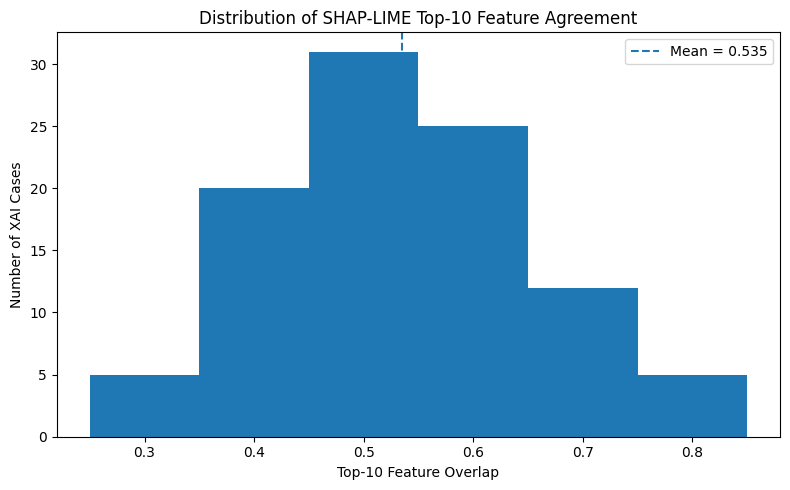

In [235]:
# SHAP-LIME Agreement Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    agreement_df["Top-10 Overlap"],
    bins=np.arange(0.25, 0.91, 0.1)
)

plt.axvline(
    agreement_df["Top-10 Overlap"].mean(),
    linestyle="--",
    label=(
        f'Mean = '
        f'{agreement_df["Top-10 Overlap"].mean():.3f}'
    )
)

plt.xlabel("Top-10 Feature Overlap")
plt.ylabel("Number of XAI Cases")

plt.title(
    "Distribution of SHAP-LIME "
    "Top-10 Feature Agreement"
)

plt.legend()
plt.tight_layout()
plt.show()

In [236]:
# Task 8 Final XAI Summary

task8_summary = pd.DataFrame({
    "XAI Metric": [
        "XAI Cases",
        "Disease Classes Represented",
        "Global SHAP Top Feature",
        "Global LIME Top Feature",
        "Global SHAP-LIME Top-20 Overlap",
        "Mean Local Top-10 Overlap",
        "Median Local Top-10 Overlap",
        "Mean Local Spearman Rho",
        "Median Local Spearman Rho",
        "Valid Local Agreement Cases"
    ],

    "Value": [
        len(X_xai_sample),
        y_xai_sample.nunique(),
        shap_importance_df.iloc[0]["Symptom"],
        lime_importance_df.iloc[0]["Symptom"],
        global_overlap,
        agreement_df["Top-10 Overlap"].mean(),
        agreement_df["Top-10 Overlap"].median(),
        agreement_df["Spearman Rho"].mean(),
        agreement_df["Spearman Rho"].median(),
        agreement_df["Spearman Rho"].notna().sum()
    ]
})

print("Task 8: Final XAI Evaluation Summary")

display(task8_summary)

Task 8: Final XAI Evaluation Summary


,XAI Metric,Value
0,XAI Cases,100
1,Disease Classes Represented,100
2,Global SHAP Top Feature,headache
3,Global LIME Top Feature,symptoms of the face
4,Global SHAP-LIME Top-20 Overlap,0.05
5,Mean Local Top-10 Overlap,0.535
6,Median Local Top-10 Overlap,0.5
7,Mean Local Spearman Rho,0.327286
8,Median Local Spearman Rho,0.4
9,Valid Local Agreement Cases,100


# TASK 9: Hybrid Explanation Fusion (HEF)

In [237]:
# Local HEF Feature Alignment

instance_idx = 0

# SHAP attribution vector
shap_vector = (
    shap_predicted_class_values[
        instance_idx
    ]
)

shap_aligned = pd.DataFrame({
    "Symptom": feature_names,
    "SHAP Raw": shap_vector
})

shap_aligned["SHAP Absolute"] = (
    shap_aligned["SHAP Raw"].abs()
)

shap_total = (
    shap_aligned["SHAP Absolute"].sum()
)

shap_aligned["SHAP Normalised"] = (
    shap_aligned["SHAP Absolute"]
    / shap_total
)


# LIME attribution vector
lime_aligned = pd.DataFrame({
    "Symptom": feature_names,
    "LIME Raw": 0.0
})


# IMPORTANT:
# use cleaned LIME feature names
lime_weight_map = dict(
    zip(
        lime_local_df["Symptom Clean"],
        lime_local_df["LIME Weight"]
    )
)


lime_aligned["LIME Raw"] = (
    lime_aligned["Symptom"]
    .map(lime_weight_map)
    .fillna(0.0)
)


lime_aligned["LIME Absolute"] = (
    lime_aligned["LIME Raw"].abs()
)


lime_total = (
    lime_aligned["LIME Absolute"].sum()
)


if lime_total > 0:

    lime_aligned["LIME Normalised"] = (
        lime_aligned["LIME Absolute"]
        / lime_total
    )

else:

    lime_aligned["LIME Normalised"] = 0.0


# Align SHAP and LIME
hef_alignment_df = pd.merge(
    shap_aligned,
    lime_aligned,
    on="Symptom",
    how="outer"
)


hef_alignment_df["Combined Importance"] = (
    hef_alignment_df["SHAP Normalised"]
    +
    hef_alignment_df["LIME Normalised"]
)


hef_alignment_df = (
    hef_alignment_df
    .sort_values(
        "Combined Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("HEF Feature Alignment Completed")

print(
    "SHAP Normalised Sum:",
    round(
        hef_alignment_df[
            "SHAP Normalised"
        ].sum(),
        4
    )
)

print(
    "LIME Normalised Sum:",
    round(
        hef_alignment_df[
            "LIME Normalised"
        ].sum(),
        4
    )
)


display(
    hef_alignment_df[
        [
            "Symptom",
            "SHAP Raw",
            "LIME Raw",
            "SHAP Normalised",
            "LIME Normalised"
        ]
    ]
    .head(15)
    .round(6)
)

HEF Feature Alignment Completed
SHAP Normalised Sum: 1.0
LIME Normalised Sum: 1.0


,Symptom,SHAP Raw,LIME Raw,SHAP Normalised,LIME Normalised
0,symptoms of the face,6.145321,0.826191,0.825862,0.900715
1,skin irritation,0.438821,0.010369,0.058973,0.011304
2,skin moles,-0.062178,-0.022769,0.008356,0.024822
3,skin lesion,0.217666,0.000000,0.029252,0.000000
4,skin growth,-0.060133,-0.014795,0.008081,0.016130
5,itching of skin,0.154505,0.000000,0.020764,0.000000
6,itchy ear(s),0.000000,0.015167,0.000000,0.016535
7,abnormal appearing skin,0.118783,0.000000,0.015963,0.000000
8,irregular appearing scalp,-0.044791,-0.006150,0.006019,0.006704
9,"skin dryness, peeling, scaliness, or roughness",-0.027329,-0.008034,0.003673,0.008759


In [238]:
# SHAP-LIME Directional Agreement
hef_alignment_df["SHAP Direction"] = (
    np.sign(
        hef_alignment_df["SHAP Raw"]
    )
)

hef_alignment_df["LIME Direction"] = (
    np.sign(
        hef_alignment_df["LIME Raw"]
    )
)


hef_alignment_df["Shared Feature"] = (
    (
        hef_alignment_df[
            "SHAP Absolute"
        ] > 0
    )
    &
    (
        hef_alignment_df[
            "LIME Absolute"
        ] > 0
    )
)


hef_alignment_df["Direction Agreement"] = (
    (
        hef_alignment_df["SHAP Direction"]
        ==
        hef_alignment_df["LIME Direction"]
    )
    &
    hef_alignment_df["Shared Feature"]
).astype(int)


shared_hef_features = (
    hef_alignment_df[
        hef_alignment_df["Shared Feature"]
    ]
    .copy()
    .sort_values(
        "Combined Importance",
        ascending=False
    )
)


direction_agreement_rate = (
    shared_hef_features[
        "Direction Agreement"
    ].mean()
)


print(
    "Number of Shared Features:",
    len(shared_hef_features)
)

print(
    "Features with Same Direction:",
    shared_hef_features[
        "Direction Agreement"
    ].sum()
)

print(
    "Directional Agreement Rate:",
    round(
        direction_agreement_rate,
        4
    )
)


display(
    shared_hef_features[
        [
            "Symptom",
            "SHAP Raw",
            "LIME Raw",
            "SHAP Normalised",
            "LIME Normalised",
            "Direction Agreement"
        ]
    ]
    .head(15)
    .round(6)
)

Number of Shared Features: 6
Features with Same Direction: 6
Directional Agreement Rate: 1.0


,Symptom,SHAP Raw,LIME Raw,SHAP Normalised,LIME Normalised,Direction Agreement
0,symptoms of the face,6.145321,0.826191,0.825862,0.900715,1
1,skin irritation,0.438821,0.010369,0.058973,0.011304,1
2,skin moles,-0.062178,-0.022769,0.008356,0.024822,1
4,skin growth,-0.060133,-0.014795,0.008081,0.016130,1
8,irregular appearing scalp,-0.044791,-0.006150,0.006019,0.006704,1
9,"skin dryness, peeling, scaliness, or roughness",-0.027329,-0.008034,0.003673,0.008759,1


In [239]:
# Local HEF Fusion
SHAP_WEIGHT = 0.5
LIME_WEIGHT = 0.5


hef_alignment_df["HEF Score"] = (
    SHAP_WEIGHT
    * hef_alignment_df["SHAP Normalised"]
    +
    LIME_WEIGHT
    * hef_alignment_df["LIME Normalised"]
)


def assign_direction_status(row):

    shap_present = (
        row["SHAP Absolute"] > 0
    )

    lime_present = (
        row["LIME Absolute"] > 0
    )

    if shap_present and lime_present:

        if (
            row["SHAP Direction"]
            ==
            row["LIME Direction"]
        ):
            return "Agreement"

        return "Conflict"

    elif shap_present:
        return "SHAP Only"

    elif lime_present:
        return "LIME Only"

    else:
        return "Neither"


hef_alignment_df["Direction Status"] = (
    hef_alignment_df.apply(
        assign_direction_status,
        axis=1
    )
)


hef_local_df = (
    hef_alignment_df
    .sort_values(
        "HEF Score",
        ascending=False
    )
    .reset_index(drop=True)
)


hef_local_df["HEF Rank"] = (
    np.arange(
        1,
        len(hef_local_df) + 1
    )
)


print(
    "Top 15 Features According to HEF"
)

display(
    hef_local_df[
        [
            "Symptom",
            "SHAP Normalised",
            "LIME Normalised",
            "HEF Score",
            "Direction Status",
            "HEF Rank"
        ]
    ]
    .head(15)
    .round(6)
)


print(
    "\nHEF Score Sum:",
    round(
        hef_local_df[
            "HEF Score"
        ].sum(),
        4
    )
)

Top 15 Features According to HEF


,Symptom,SHAP Normalised,LIME Normalised,HEF Score,Direction Status,HEF Rank
0,symptoms of the face,0.825862,0.900715,0.863288,Agreement,1
1,skin irritation,0.058973,0.011304,0.035138,Agreement,2
2,skin moles,0.008356,0.024822,0.016589,Agreement,3
3,skin lesion,0.029252,0.000000,0.014626,SHAP Only,4
4,skin growth,0.008081,0.016130,0.012105,Agreement,5
5,itching of skin,0.020764,0.000000,0.010382,SHAP Only,6
6,itchy ear(s),0.000000,0.016535,0.008267,LIME Only,7
7,abnormal appearing skin,0.015963,0.000000,0.007982,SHAP Only,8
8,irregular appearing scalp,0.006019,0.006704,0.006362,Agreement,9
9,"skin dryness, peeling, scaliness, or roughness",0.003673,0.008759,0.006216,Agreement,10



HEF Score Sum: 1.0


In [240]:
# Systematic HEF Analysis

In [241]:
# Across 100 XAI Cases
all_hef_results = []
hef_case_summaries = []

for i in range(len(X_xai_sample)):

    predicted_class = int(xai_pred[i])

    # SHAP Attribution
    shap_raw = shap_predicted_class_values[i]

    shap_abs = np.abs(shap_raw)

    shap_total = shap_abs.sum()

    if shap_total > 0:
        shap_norm = shap_abs / shap_total
    else:
        shap_norm = shap_abs


    # LIME Attribution
    # Top-10 local features
    lime_exp_i = lime_explainer.explain_instance(
        data_row=X_xai_sample.iloc[i].to_numpy(),
        predict_fn=xgb_final.predict_proba,
        labels=[predicted_class],
        num_features=10,
        num_samples=2000
    )

    lime_list_i = lime_exp_i.as_list(
        label=predicted_class
    )

    lime_df_i = pd.DataFrame(
        lime_list_i,
        columns=[
            "Symptom",
            "LIME Weight"
        ]
    )

    # Clean categorical suffixes (=0 / =1)
    lime_df_i["Symptom Clean"] = (
        lime_df_i["Symptom"]
        .str.replace(
            r"=[01]$",
            "",
            regex=True
        )
    )

    lime_weight_map = dict(
        zip(
            lime_df_i["Symptom Clean"],
            lime_df_i["LIME Weight"]
        )
    )

    # Align LIME to all 230 symptoms
    lime_raw = np.array([
        lime_weight_map.get(
            feature,
            0.0
        )
        for feature in feature_names
    ])

    lime_abs = np.abs(lime_raw)

    lime_total = lime_abs.sum()

    if lime_total > 0:
        lime_norm = lime_abs / lime_total
    else:
        lime_norm = lime_abs

    # HEF Equal-Weight Fusion
    hef_score = (
        0.5 * shap_norm
        +
        0.5 * lime_norm
    )

    # Attribution Direction
    shap_direction = np.sign(
        shap_raw
    )

    lime_direction = np.sign(
        lime_raw
    )

    shared = (
        (shap_abs > 0)
        &
        (lime_abs > 0)
    )

    direction_agreement = (
        shared
        &
        (
            shap_direction
            ==
            lime_direction
        )
    )


    # Case-Level Feature Table
    case_df = pd.DataFrame({
        "Case": i + 1,
        "Symptom": feature_names,
        "SHAP Raw": shap_raw,
        "LIME Raw": lime_raw,
        "SHAP Normalised": shap_norm,
        "LIME Normalised": lime_norm,
        "HEF Score": hef_score,
        "Shared Feature": shared,
        "Direction Agreement":
            direction_agreement
    })

    case_df = (
        case_df
        .sort_values(
            "HEF Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    case_df["HEF Rank"] = np.arange(
        1,
        len(case_df) + 1
    )

    all_hef_results.append(
        case_df
    )

    # Case-Level Summary
    shared_count = int(
        shared.sum()
    )

    if shared_count > 0:

        direction_rate = (
            direction_agreement.sum()
            / shared_count
        )

    else:

        direction_rate = np.nan


    true_class = int(
        y_xai_sample.iloc[i]
    )


    hef_case_summaries.append({

        "Case": i + 1,

        "True Disease":
            label_encoder.inverse_transform(
                [true_class]
            )[0],

        "Predicted Disease":
            label_encoder.inverse_transform(
                [predicted_class]
            )[0],

        "Shared Features":
            shared_count,

        "Directional Agreement Rate":
            direction_rate,

        "Top HEF Feature":
            case_df.iloc[0][
                "Symptom"
            ],

        "Top HEF Score":
            case_df.iloc[0][
                "HEF Score"
            ]
    })

# Combine HEF Results
hef_all_df = pd.concat(
    all_hef_results,
    ignore_index=True
)

hef_summary_df = pd.DataFrame(
    hef_case_summaries
)


print(
    "Total XAI Cases:",
    len(hef_summary_df)
)

print(
    "Total HEF Feature Records:",
    len(hef_all_df)
)

display(
    hef_summary_df
    .head(10)
    .round(4)
)

Total XAI Cases: 100
Total HEF Feature Records: 23000


,Case,True Disease,Predicted Disease,Shared Features,Directional Agreement Rate,Top HEF Feature,Top HEF Score
0,1,actinic keratosis,actinic keratosis,5,1.0000,symptoms of the face,0.8352
1,2,acute bronchiolitis,acute bronchiolitis,6,1.0000,irritable infant,0.3071
2,3,acute bronchitis,chronic obstructive pulmonary disease (copd),5,1.0000,congestion in chest,0.2716
3,4,acute bronchospasm,acute bronchospasm,6,1.0000,chest tightness,0.3225
4,5,acute kidney injury,acute kidney injury,6,0.8333,kidney mass,0.2430
5,6,acute pancreatitis,acute pancreatitis,3,1.0000,hemoptysis,0.5131
6,7,acute sinusitis,croup,5,1.0000,hoarse voice,0.3514
7,8,allergy,allergy,8,1.0000,fluid retention,0.2792
8,9,angina,angina,6,1.0000,hot flashes,0.6323
9,10,anxiety,panic disorder,5,1.0000,breathing fast,0.2948


In [242]:
# Overall HEF Summary
hef_overall_summary = pd.DataFrame({
    "Metric": [
        "Mean Shared Features",
        "Median Shared Features",
        "Minimum Shared Features",
        "Maximum Shared Features",
        "Mean Directional Agreement",
        "Median Directional Agreement",
        "Minimum Directional Agreement",
        "Maximum Directional Agreement"
    ],

    "Value": [
        hef_summary_df["Shared Features"].mean(),
        hef_summary_df["Shared Features"].median(),
        hef_summary_df["Shared Features"].min(),
        hef_summary_df["Shared Features"].max(),

        hef_summary_df["Directional Agreement Rate"].mean(),
        hef_summary_df["Directional Agreement Rate"].median(),
        hef_summary_df["Directional Agreement Rate"].min(),
        hef_summary_df["Directional Agreement Rate"].max()
    ]
})

print("Overall HEF Summary")

display(
    hef_overall_summary.round(4)
)

Overall HEF Summary


,Metric,Value
0,Mean Shared Features,6.0900
1,Median Shared Features,6.0000
2,Minimum Shared Features,3.0000
3,Maximum Shared Features,9.0000
4,Mean Directional Agreement,0.9801
5,Median Directional Agreement,1.0000
6,Minimum Directional Agreement,0.6667
7,Maximum Directional Agreement,1.0000


In [243]:
# Source Status of Top-Ranked HEF Feature

In [244]:
top_hef_records = (
    hef_all_df[
        hef_all_df["HEF Rank"] == 1
    ]
    .copy()
)


def top_feature_status(row):

    shap_present = (
        row["SHAP Normalised"] > 0
    )

    lime_present = (
        row["LIME Normalised"] > 0
    )

    if shap_present and lime_present:

        if row["Direction Agreement"]:
            return "Both - Same Direction"

        else:
            return "Both - Direction Conflict"

    elif shap_present:
        return "SHAP Only"

    elif lime_present:
        return "LIME Only"

    else:
        return "Neither"


top_hef_records["Top Feature Status"] = (
    top_hef_records.apply(
        top_feature_status,
        axis=1
    )
)


top_feature_summary = (
    top_hef_records[
        "Top Feature Status"
    ]
    .value_counts()
    .rename_axis("Status")
    .reset_index(
        name="Number of Cases"
    )
)


top_feature_summary["Percentage"] = (
    top_feature_summary[
        "Number of Cases"
    ]
    / len(top_hef_records)
    * 100
)


print(
    "Source Agreement of "
    "Top-Ranked HEF Features"
)

display(
    top_feature_summary.round(2)
)

Source Agreement of Top-Ranked HEF Features


,Status,Number of Cases,Percentage
0,Both - Same Direction,97,97.0
1,Both - Direction Conflict,3,3.0


In [245]:
# HEF Ranking Validation

In [246]:
hef_validation_results = []

for i in range(len(X_xai_sample)):

    case_hef = (
        hef_all_df[
            hef_all_df["Case"] == i + 1
        ]
        .copy()
    )

    # Top-10 HEF
    hef_top10 = set(
        case_hef
        .sort_values(
            "HEF Score",
            ascending=False
        )
        .head(10)["Symptom"]
    )

    # Top-10 SHAP
    shap_top10 = set(
        case_hef
        .sort_values(
            "SHAP Normalised",
            ascending=False
        )
        .head(10)["Symptom"]
    )

    # Top-10 LIME
    lime_top10 = set(
        case_hef
        .sort_values(
            "LIME Normalised",
            ascending=False
        )
        .head(10)["Symptom"]
    )

    # HEF-SHAP overlap
    hef_shap_overlap = (
        len(
            hef_top10.intersection(
                shap_top10
            )
        )
        / 10
    )

    # HEF-LIME overlap
    hef_lime_overlap = (
        len(
            hef_top10.intersection(
                lime_top10
            )
        )
        / 10
    )

    hef_validation_results.append({
        "Case": i + 1,
        "HEF-SHAP Top-10 Overlap":
            hef_shap_overlap,
        "HEF-LIME Top-10 Overlap":
            hef_lime_overlap
    })


hef_validation_df = pd.DataFrame(
    hef_validation_results
)


hef_validation_summary = pd.DataFrame({
    "Metric": [
        "Mean HEF-SHAP Top-10 Overlap",
        "Mean HEF-LIME Top-10 Overlap",
        "Median HEF-SHAP Top-10 Overlap",
        "Median HEF-LIME Top-10 Overlap"
    ],

    "Value": [
        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].median(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].median()
    ]
})


print("HEF Ranking Validation")

display(
    hef_validation_summary.round(4)
)

HEF Ranking Validation


,Metric,Value
0,Mean HEF-SHAP Top-10 Overlap,0.705
1,Mean HEF-LIME Top-10 Overlap,0.821
2,Median HEF-SHAP Top-10 Overlap,0.700
3,Median HEF-LIME Top-10 Overlap,0.800


In [247]:
# Verify LIME Contribution to HEF
lime_nonzero_per_case = (
    hef_all_df
    .groupby("Case")["LIME Normalised"]
    .apply(lambda x: (x > 0).sum())
)

lime_contribution_check = pd.DataFrame({
    "Metric": [
        "Minimum Non-Zero LIME Features",
        "Maximum Non-Zero LIME Features",
        "Mean Non-Zero LIME Features",
        "Cases with Exactly 10 Features"
    ],

    "Value": [
        lime_nonzero_per_case.min(),
        lime_nonzero_per_case.max(),
        lime_nonzero_per_case.mean(),
        (lime_nonzero_per_case == 10).sum()
    ]
})

print("HEF LIME Contribution Verification")

display(
    lime_contribution_check.round(4)
)

HEF LIME Contribution Verification


,Metric,Value
0,Minimum Non-Zero LIME Features,10.0
1,Maximum Non-Zero LIME Features,10.0
2,Mean Non-Zero LIME Features,10.0
3,Cases with Exactly 10 Features,100.0


In [248]:
# Final HEF Summary
task9_summary = pd.DataFrame({
    "HEF Metric": [
        "XAI Cases",
        "Mean Shared Features",
        "Median Shared Features",
        "Mean Directional Agreement",
        "Median Directional Agreement",
        "Top-1 Same-Direction Agreement",
        "Top-1 Direction Conflict",
        "Mean HEF-SHAP Top-10 Overlap",
        "Mean HEF-LIME Top-10 Overlap",
        "Median HEF-SHAP Top-10 Overlap",
        "Median HEF-LIME Top-10 Overlap"
    ],

    "Value": [
        len(hef_summary_df),

        hef_summary_df[
            "Shared Features"
        ].mean(),

        hef_summary_df[
            "Shared Features"
        ].median(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].mean(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].median(),

        (
            top_hef_records[
                "Top Feature Status"
            ]
            .eq("Both - Same Direction")
            .mean()
        ),

        (
            top_hef_records[
                "Top Feature Status"
            ]
            .eq("Both - Direction Conflict")
            .mean()
        ),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].median(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].median()
    ]
})

print("Task 9: Final HEF Evaluation Summary")

display(
    task9_summary.round(4)
)

Task 9: Final HEF Evaluation Summary


,HEF Metric,Value
0,XAI Cases,100.0000
1,Mean Shared Features,6.0900
2,Median Shared Features,6.0000
3,Mean Directional Agreement,0.9801
4,Median Directional Agreement,1.0000
5,Top-1 Same-Direction Agreement,0.9700
6,Top-1 Direction Conflict,0.0300
7,Mean HEF-SHAP Top-10 Overlap,0.7050
8,Mean HEF-LIME Top-10 Overlap,0.8210
9,Median HEF-SHAP Top-10 Overlap,0.7000


# TASK 10: Trust Consistency Index (TCI)

In [249]:
# TCI Agreement Component

In [250]:
from scipy.stats import spearmanr

tci_agreement_df = agreement_df[
    [
        "Case",
        "Top-10 Overlap",
        "Spearman Rho"
    ]
].copy()

# Convert Spearman correlation from [-1, 1] to [0, 1]
tci_agreement_df["Rank Agreement Score"] = (
    tci_agreement_df["Spearman Rho"] + 1
) / 2

# Add directional agreement from HEF
tci_agreement_df = pd.merge(
    tci_agreement_df,
    hef_summary_df[
        [
            "Case",
            "Directional Agreement Rate"
        ]
    ],
    on="Case",
    how="left"
)

tci_agreement_df = tci_agreement_df.rename(
    columns={
        "Directional Agreement Rate":
            "Directional Agreement"
    }
)

# Equal-weight combination of three agreement measures
tci_agreement_df["TCI Agreement Score"] = (
    tci_agreement_df[
        [
            "Top-10 Overlap",
            "Rank Agreement Score",
            "Directional Agreement"
        ]
    ]
    .mean(axis=1)
)

print(
    "TCI Agreement Component "
    "calculated successfully."
)

display(
    tci_agreement_df.head(10).round(4)
)

TCI Agreement Component calculated successfully.


,Case,Top-10 Overlap,Spearman Rho,Rank Agreement Score,Directional Agreement,TCI Agreement Score
0,1,0.5,0.7000,0.8500,1.0000,0.7833
1,2,0.5,0.8000,0.9000,1.0000,0.8000
2,3,0.4,-0.2000,0.4000,1.0000,0.6000
3,4,0.5,0.1000,0.5500,1.0000,0.6833
4,5,0.3,1.0000,1.0000,0.8333,0.7111
5,6,0.4,0.4000,0.7000,1.0000,0.7000
6,7,0.3,-0.5000,0.2500,1.0000,0.5167
7,8,0.9,0.2000,0.6000,1.0000,0.8333
8,9,0.4,1.0000,1.0000,1.0000,0.8000
9,10,0.6,-0.0857,0.4571,1.0000,0.6857


In [251]:
# Agreement Component Summary
agreement_component_summary = pd.DataFrame({
    "Metric": [
        "Mean TCI Agreement Score",
        "Median TCI Agreement Score",
        "Minimum TCI Agreement Score",
        "Maximum TCI Agreement Score"
    ],

    "Value": [
        tci_agreement_df[
            "TCI Agreement Score"
        ].mean(),

        tci_agreement_df[
            "TCI Agreement Score"
        ].median(),

        tci_agreement_df[
            "TCI Agreement Score"
        ].min(),

        tci_agreement_df[
            "TCI Agreement Score"
        ].max()
    ]
})

display(
    agreement_component_summary.round(4)
)

,Metric,Value
0,Mean TCI Agreement Score,0.7263
1,Median TCI Agreement Score,0.7384
2,Minimum TCI Agreement Score,0.4000
3,Maximum TCI Agreement Score,0.8667


In [252]:
# LIME Stability Component
from itertools import combinations
from lime.lime_tabular import LimeTabularExplainer

N_REPEATS = 5
TOP_K = 10

stability_seeds = [
    42,
    52,
    62,
    72,
    82
]

stability_results = []

categorical_feature_indices = list(
    range(len(feature_names))
)

for i in range(len(X_xai_sample)):

    predicted_class = int(
        xai_pred[i]
    )

    repeated_feature_sets = []

    for seed in stability_seeds:

        temp_explainer = LimeTabularExplainer(
            training_data=X_train.to_numpy(),
            feature_names=feature_names,
            class_names=label_encoder.classes_.tolist(),
            mode="classification",
            categorical_features=
                categorical_feature_indices,
            discretize_continuous=False,
            random_state=seed
        )

        exp = temp_explainer.explain_instance(
            data_row=X_xai_sample
                .iloc[i]
                .to_numpy(),

            predict_fn=xgb_final.predict_proba,

            labels=[predicted_class],

            num_features=TOP_K,

            num_samples=2000
        )

        lime_features_run = []

        for feature, weight in exp.as_list(
            label=predicted_class
        ):

            # Remove =0 / =1 suffix
            clean_feature = (
                feature
                .replace("=0", "")
                .replace("=1", "")
            )

            lime_features_run.append(
                clean_feature
            )

        repeated_feature_sets.append(
            set(lime_features_run)
        )

    # Pairwise Top-10 overlap
    pairwise_scores = []

    for set_a, set_b in combinations(
        repeated_feature_sets,
        2
    ):

        overlap = (
            len(
                set_a.intersection(set_b)
            )
            / TOP_K
        )

        pairwise_scores.append(
            overlap
        )

    stability_score = np.mean(
        pairwise_scores
    )

    stability_results.append({
        "Case": i + 1,
        "LIME Stability Score":
            stability_score
    })

    if (i + 1) % 10 == 0:

        print(
            f"Completed stability analysis "
            f"for {i + 1}/100 cases"
        )


tci_stability_df = pd.DataFrame(
    stability_results
)

print(
    "\nTCI Stability Component "
    "calculated successfully."
)

display(
    tci_stability_df
    .head(10)
    .round(4)
)

Completed stability analysis for 10/100 cases
Completed stability analysis for 20/100 cases
Completed stability analysis for 30/100 cases
Completed stability analysis for 40/100 cases
Completed stability analysis for 50/100 cases
Completed stability analysis for 60/100 cases
Completed stability analysis for 70/100 cases
Completed stability analysis for 80/100 cases
Completed stability analysis for 90/100 cases
Completed stability analysis for 100/100 cases

TCI Stability Component calculated successfully.


,Case,LIME Stability Score
0,1,0.51
1,2,0.49
2,3,0.48
3,4,0.54
4,5,0.54
5,6,0.52
6,7,0.55
7,8,0.64
8,9,0.51
9,10,0.63


In [253]:
# Stability Component Summary

In [254]:
stability_component_summary = pd.DataFrame({
    "Metric": [
        "Mean LIME Stability Score",
        "Median LIME Stability Score",
        "Minimum LIME Stability Score",
        "Maximum LIME Stability Score"
    ],

    "Value": [
        tci_stability_df[
            "LIME Stability Score"
        ].mean(),

        tci_stability_df[
            "LIME Stability Score"
        ].median(),

        tci_stability_df[
            "LIME Stability Score"
        ].min(),

        tci_stability_df[
            "LIME Stability Score"
        ].max()
    ]
})

print("TCI Stability Summary")

display(
    stability_component_summary.round(4)
)

TCI Stability Summary


,Metric,Value
0,Mean LIME Stability Score,0.5722
1,Median LIME Stability Score,0.5700
2,Minimum LIME Stability Score,0.3400
3,Maximum LIME Stability Score,0.7700


In [255]:
# SHAP Explanation Sensitivity
# Binary Feature Perturbation
TOP_K = 10
PERTURBATION_RATE = 0.02

rng = np.random.default_rng(42)

sensitivity_results = []

for i in range(len(X_xai_sample)):

    predicted_class = int(
        xai_pred[i]
    )

    # Original SHAP explanation
    original_shap = (
        shap_predicted_class_values[i]
    )

    original_top_idx = np.argsort(
        np.abs(original_shap)
    )[-TOP_K:]

    original_features = set(
        np.array(feature_names)[
            original_top_idx
        ]
    )

    # Original binary symptom vector
    original_instance = (
        X_xai_sample
        .iloc[i]
        .to_numpy()
        .astype(float)
        .copy()
    )

    # Create perturbed copy
    perturbed_instance = (
        original_instance.copy()
    )

    # Number of binary symptoms to flip
    n_features_to_flip = max(
        1,
        int(
            round(
                len(feature_names)
                * PERTURBATION_RATE
            )
        )
    )

    # Randomly select symptoms
    flip_indices = rng.choice(
        len(feature_names),
        size=n_features_to_flip,
        replace=False
    )

    # Binary perturbation: 0 -> 1 and 1 -> 0
    perturbed_instance[
        flip_indices
    ] = (
        1
        - perturbed_instance[
            flip_indices
        ]
    )

    perturbed_instance_2d = (
        perturbed_instance.reshape(
            1,
            -1
        )
    )

    # Prediction after perturbation
    perturbed_prediction = int(
        xgb_final.predict(
            perturbed_instance_2d
        )[0]
    )

    prediction_preserved = (
        perturbed_prediction
        ==
        predicted_class
    )

    # SHAP explanation for perturbed instance
    perturbed_shap_output = (
        shap_explainer(
            perturbed_instance_2d
        )
    )

    # Keep explanation for original predicted class
    perturbed_shap = (
        perturbed_shap_output.values[
            0,
            :,
            predicted_class
        ]
    )

    perturbed_top_idx = np.argsort(
        np.abs(perturbed_shap)
    )[-TOP_K:]

    perturbed_features = set(
        np.array(feature_names)[
            perturbed_top_idx
        ]
    )

    # Top-10 SHAP feature overlap
    feature_overlap = (
        len(
            original_features.intersection(
                perturbed_features
            )
        )
        / TOP_K
    )

    sensitivity_results.append({
        "Case": i + 1,
        "Prediction Preserved":
            prediction_preserved,
        "Sensitivity Robustness Score":
            feature_overlap,
        "Features Perturbed":
            n_features_to_flip
    })


tci_sensitivity_df = pd.DataFrame(
    sensitivity_results
)

print(
    "TCI Sensitivity Component "
    "calculated successfully."
)

display(
    tci_sensitivity_df
    .head(10)
    .round(4)
)

TCI Sensitivity Component calculated successfully.


,Case,Prediction Preserved,Sensitivity Robustness Score,Features Perturbed
0,1,True,0.9,5
1,2,True,1.0,5
2,3,False,0.8,5
3,4,False,1.0,5
4,5,True,1.0,5
5,6,True,0.9,5
6,7,False,1.0,5
7,8,True,1.0,5
8,9,True,1.0,5
9,10,False,0.9,5


In [256]:
# Sensitivity Component Summary

In [257]:
sensitivity_component_summary = pd.DataFrame({
    "Metric": [
        "Mean Sensitivity Robustness Score",
        "Median Sensitivity Robustness Score",
        "Minimum Sensitivity Robustness Score",
        "Maximum Sensitivity Robustness Score",
        "Prediction Preservation Rate",
        "Predictions Preserved",
        "Predictions Changed",
        "Features Perturbed per Case"
    ],

    "Value": [
        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].median(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].min(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].max(),

        tci_sensitivity_df[
            "Prediction Preserved"
        ].mean(),

        tci_sensitivity_df[
            "Prediction Preserved"
        ].sum(),

        (
            ~tci_sensitivity_df[
                "Prediction Preserved"
            ]
        ).sum(),

        tci_sensitivity_df[
            "Features Perturbed"
        ].iloc[0]
    ]
})

print("TCI Sensitivity Summary")

display(
    sensitivity_component_summary.round(4)
)

TCI Sensitivity Summary


,Metric,Value
0,Mean Sensitivity Robustness Score,0.965
1,Median Sensitivity Robustness Score,1.000
2,Minimum Sensitivity Robustness Score,0.800
3,Maximum Sensitivity Robustness Score,1.000
4,Prediction Preservation Rate,0.720
5,Predictions Preserved,72.000
6,Predictions Changed,28.000
7,Features Perturbed per Case,5.000


In [258]:
# Final Trust Consistency Index
tci_final_df = (
    tci_agreement_df[
        [
            "Case",
            "TCI Agreement Score"
        ]
    ]
    .merge(
        tci_stability_df[
            [
                "Case",
                "LIME Stability Score"
            ]
        ],
        on="Case",
        how="inner"
    )
    .merge(
        tci_sensitivity_df[
            [
                "Case",
                "Prediction Preserved",
                "Sensitivity Robustness Score"
            ]
        ],
        on="Case",
        how="inner"
    )
)

# Equal-weight TCI across all 100 XAI cases
tci_final_df["TCI"] = (
    tci_final_df[
        [
            "TCI Agreement Score",
            "LIME Stability Score",
            "Sensitivity Robustness Score"
        ]
    ]
    .mean(axis=1)
)

print("Final TCI calculated successfully.")

print(
    "Total TCI Cases:",
    len(tci_final_df)
)

print(
    "Prediction-Preserved Cases:",
    tci_final_df["Prediction Preserved"].sum()
)

print(
    "Prediction-Changed Cases:",
    (~tci_final_df["Prediction Preserved"]).sum()
)

display(
    tci_final_df.head(10).round(4)
)

Final TCI calculated successfully.
Total TCI Cases: 100
Prediction-Preserved Cases: 72
Prediction-Changed Cases: 28


,Case,TCI Agreement Score,LIME Stability Score,Prediction Preserved,Sensitivity Robustness Score,TCI
0,1,0.7833,0.51,True,0.9,0.7311
1,2,0.8000,0.49,True,1.0,0.7633
2,3,0.6000,0.48,False,0.8,0.6267
3,4,0.6833,0.54,False,1.0,0.7411
4,5,0.7111,0.54,True,1.0,0.7504
5,6,0.7000,0.52,True,0.9,0.7067
6,7,0.5167,0.55,False,1.0,0.6889
7,8,0.8333,0.64,True,1.0,0.8244
8,9,0.8000,0.51,True,1.0,0.7700
9,10,0.6857,0.63,False,0.9,0.7386


In [259]:
# Trust Consistency Index Summary
tci_summary = pd.DataFrame({
    "Metric": [
        "Mean TCI",
        "Median TCI",
        "Standard Deviation",
        "Minimum TCI",
        "Maximum TCI",
        "Total TCI Cases",
        "Prediction Preservation Rate"
    ],

    "Value": [
        tci_final_df["TCI"].mean(),
        tci_final_df["TCI"].median(),
        tci_final_df["TCI"].std(),
        tci_final_df["TCI"].min(),
        tci_final_df["TCI"].max(),
        len(tci_final_df),
        tci_final_df["Prediction Preserved"].mean()
    ]
})

print("Trust Consistency Index Summary")

display(
    tci_summary.round(4)
)

Trust Consistency Index Summary


,Metric,Value
0,Mean TCI,0.7545
1,Median TCI,0.7653
2,Standard Deviation,0.0565
3,Minimum TCI,0.5800
4,Maximum TCI,0.8662
5,Total TCI Cases,100.0000
6,Prediction Preservation Rate,0.7200


In [260]:
# TCI Validation by Prediction Correctness
tci_validation_df = tci_final_df.copy()

# Add true disease class
tci_validation_df["True Class"] = [
    int(y_xai_sample.iloc[i])
    for i in range(len(X_xai_sample))
]

# Add predicted disease class
tci_validation_df["Predicted Class"] = [
    int(xai_pred[i])
    for i in range(len(X_xai_sample))
]

# Determine whether prediction was correct
tci_validation_df["Correct Prediction"] = (
    tci_validation_df["True Class"]
    ==
    tci_validation_df["Predicted Class"]
)

# Summary of TCI for correct and incorrect predictions
correctness_summary = (
    tci_validation_df
    .groupby("Correct Prediction")["TCI"]
    .agg(
        Count="count",
        Mean_TCI="mean",
        Median_TCI="median",
        Std_TCI="std"
    )
    .reset_index()
)

print("TCI by Prediction Correctness")

display(
    correctness_summary.round(4)
)

TCI by Prediction Correctness


,Correct Prediction,Count,Mean_TCI,Median_TCI,Std_TCI
0,False,11,0.7248,0.7335,0.0515
1,True,89,0.7582,0.7689,0.0563


In [261]:
# Statistical Comparison of TCI
from scipy.stats import mannwhitneyu

correct_tci = tci_validation_df.loc[
    tci_validation_df["Correct Prediction"],
    "TCI"
]

incorrect_tci = tci_validation_df.loc[
    ~tci_validation_df["Correct Prediction"],
    "TCI"
]

print("Correct Predictions  :", len(correct_tci))
print("Incorrect Predictions:", len(incorrect_tci))

if len(correct_tci) > 0 and len(incorrect_tci) > 0:

    u_stat, p_value = mannwhitneyu(
        correct_tci,
        incorrect_tci,
        alternative="two-sided"
    )

    print(
        "\nMann-Whitney U Statistic:",
        round(u_stat, 4)
    )

    print(
        "P-value:",
        round(p_value, 6)
    )

else:

    print(
        "\nStatistical comparison cannot be performed "
        "because one group contains no observations."
    )

Correct Predictions  : 89
Incorrect Predictions: 11

Mann-Whitney U Statistic: 670.5
P-value: 0.046757


In [262]:
# TCI vs Prediction Confidence
from scipy.stats import spearmanr

# Obtain prediction probabilities
# for the 100 XAI cases
xai_probabilities = xgb_final.predict_proba(
    X_xai_sample
)

# Confidence assigned to the predicted class
prediction_confidence = np.array([
    xai_probabilities[
        i,
        int(xai_pred[i])
    ]
    for i in range(len(X_xai_sample))
])

# Add confidence to TCI validation dataframe
tci_validation_df[
    "Prediction Confidence"
] = prediction_confidence

# Spearman correlation
confidence_rho, confidence_p = spearmanr(
    tci_validation_df["TCI"],
    tci_validation_df[
        "Prediction Confidence"
    ]
)

print(
    "Cases:",
    len(tci_validation_df)
)

print(
    "Spearman Correlation "
    "(TCI vs Confidence):",
    round(confidence_rho, 4)
)

print(
    "P-value:",
    round(confidence_p, 6)
)

print(
    "Exact P-value:",
    f"{confidence_p:.6e}"
)

display(
    tci_validation_df[
        [
            "Case",
            "TCI",
            "Prediction Confidence",
            "Correct Prediction",
            "Prediction Preserved"
        ]
    ]
    .head(10)
    .round(4)
)

Cases: 100
Spearman Correlation (TCI vs Confidence): 0.3035
P-value: 0.002144
Exact P-value: 2.144156e-03


,Case,TCI,Prediction Confidence,Correct Prediction,Prediction Preserved
0,1,0.7311,0.9690,True,True
1,2,0.7633,0.9671,True,True
2,3,0.6267,0.5285,False,False
3,4,0.7411,0.8480,True,False
4,5,0.7504,0.9798,True,True
5,6,0.7067,0.9702,True,True
6,7,0.6889,0.0661,False,False
7,8,0.8244,0.9680,True,True
8,9,0.7700,0.9645,True,True
9,10,0.7386,0.4572,False,False


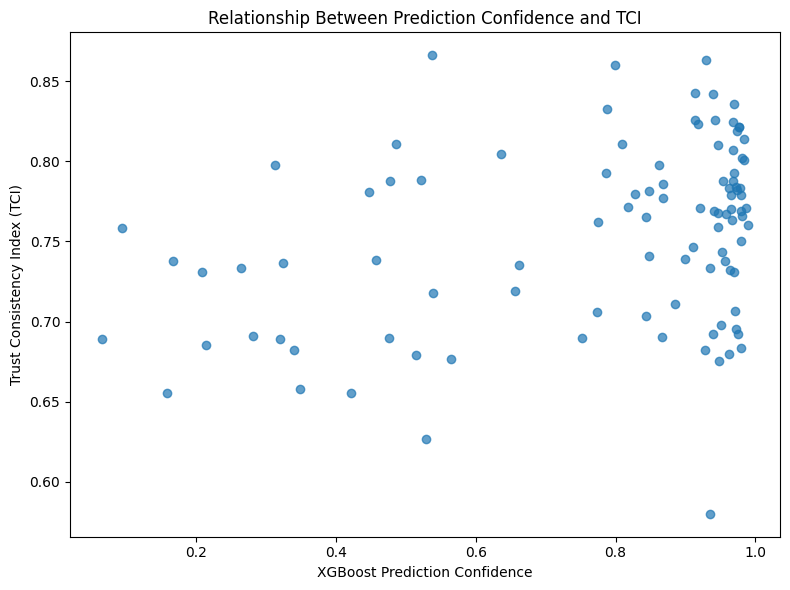

In [263]:
# TCI vs Prediction Confidence Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    tci_validation_df[
        "Prediction Confidence"
    ],
    tci_validation_df["TCI"],
    alpha=0.7
)

plt.xlabel(
    "XGBoost Prediction Confidence"
)

plt.ylabel(
    "Trust Consistency Index (TCI)"
)

plt.title(
    "Relationship Between "
    "Prediction Confidence and TCI"
)

plt.tight_layout()

plt.show()

In [264]:
# Final Task 10 TCI Summary
task10_summary = pd.DataFrame({
    "TCI Metric": [
        "XAI Cases",
        "Mean TCI",
        "Median TCI",
        "TCI Standard Deviation",
        "Minimum TCI",
        "Maximum TCI",
        "Mean Agreement Component",
        "Mean LIME Stability",
        "Mean SHAP Sensitivity Robustness",
        "Prediction Preservation Rate",
        "Mean TCI - Correct Predictions",
        "Mean TCI - Incorrect Predictions",
        "Mann-Whitney P-value",
        "TCI-Confidence Spearman Rho",
        "TCI-Confidence P-value"
    ],

    "Value": [
        len(tci_final_df),

        tci_final_df["TCI"].mean(),

        tci_final_df["TCI"].median(),

        tci_final_df["TCI"].std(),

        tci_final_df["TCI"].min(),

        tci_final_df["TCI"].max(),

        tci_final_df[
            "TCI Agreement Score"
        ].mean(),

        tci_final_df[
            "LIME Stability Score"
        ].mean(),

        tci_final_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_final_df[
            "Prediction Preserved"
        ].mean(),

        correct_tci.mean(),

        incorrect_tci.mean(),

        p_value,

        confidence_rho,

        confidence_p
    ]
})

print(
    "Task 10: Final Trust Consistency Index Summary"
)

display(
    task10_summary.round(4)
)

Task 10: Final Trust Consistency Index Summary


,TCI Metric,Value
0,XAI Cases,100.0000
1,Mean TCI,0.7545
2,Median TCI,0.7653
3,TCI Standard Deviation,0.0565
4,Minimum TCI,0.5800
5,Maximum TCI,0.8662
6,Mean Agreement Component,0.7263
7,Mean LIME Stability,0.5722
8,Mean SHAP Sensitivity Robustness,0.9650
9,Prediction Preservation Rate,0.7200


In [265]:
print(f"Spearman rho: {confidence_rho:.4f}")
print(f"Exact p-value: {confidence_p:.6e}")

Spearman rho: 0.3035
Exact p-value: 2.144156e-03


# TASK 11: Integrated Framework Evaluation

In [266]:
# Final Predictive Performance Comparison

final_model_comparison = (
    final_results[
        [
            "Model",
            "Accuracy",
            "F1 Score"
        ]
    ]
    .copy()
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

final_model_comparison["Rank"] = (
    range(
        1,
        len(final_model_comparison) + 1
    )
)

print("Final Predictive Performance Comparison")

display(
    final_model_comparison[
        [
            "Rank",
            "Model",
            "Accuracy",
            "F1 Score"
        ]
    ].round(4)
)

Final Predictive Performance Comparison


,Rank,Model,Accuracy,F1 Score
0,1,Logistic Regression (Tuned),0.8875,0.8887
1,2,XGBoost (Tuned),0.8843,0.8861
2,3,Artificial Neural Network (Tuned),0.8841,0.8847
3,4,Random Forest,0.8575,0.8578
4,5,Decision Tree,0.8421,0.8419


In [267]:
# Predictive Performance Plot

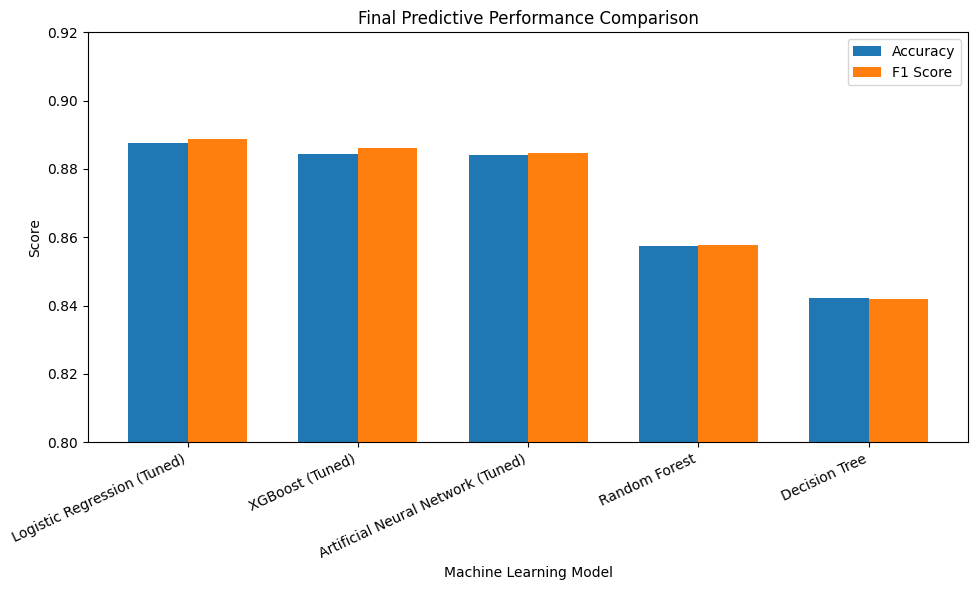

In [268]:
models_plot = final_model_comparison["Model"]
accuracy_plot = final_model_comparison["Accuracy"]
f1_plot = final_model_comparison["F1 Score"]

x = np.arange(
    len(models_plot)
)

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    accuracy_plot,
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    f1_plot,
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    models_plot,
    rotation=25,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Machine Learning Model")

plt.title(
    "Final Predictive Performance Comparison"
)

plt.ylim(0.80, 0.92)

plt.legend()
plt.tight_layout()
plt.show()

In [269]:
#  SHAP-LIME Agreement Evaluation

In [270]:
xai_evaluation_summary = pd.DataFrame({
    "XAI Evaluation Metric": [
        "Global SHAP-LIME Top-20 Overlap",
        "Mean Local SHAP-LIME Top-10 Overlap",
        "Median Local SHAP-LIME Top-10 Overlap",
        "Minimum Local Top-10 Overlap",
        "Maximum Local Top-10 Overlap",
        "Mean Local Spearman Rank Correlation",
        "Median Local Spearman Rank Correlation"
    ],

    "Value": [
        global_overlap,
        agreement_df["Top-10 Overlap"].mean(),
        agreement_df["Top-10 Overlap"].median(),
        agreement_df["Top-10 Overlap"].min(),
        agreement_df["Top-10 Overlap"].max(),
        agreement_df["Spearman Rho"].mean(),
        agreement_df["Spearman Rho"].median()
    ]
})

print("SHAP-LIME Agreement Evaluation")

display(
    xai_evaluation_summary.round(4)
)

SHAP-LIME Agreement Evaluation


,XAI Evaluation Metric,Value
0,Global SHAP-LIME Top-20 Overlap,0.0500
1,Mean Local SHAP-LIME Top-10 Overlap,0.5350
2,Median Local SHAP-LIME Top-10 Overlap,0.5000
3,Minimum Local Top-10 Overlap,0.2000
4,Maximum Local Top-10 Overlap,0.9000
5,Mean Local Spearman Rank Correlation,0.3273
6,Median Local Spearman Rank Correlation,0.4000


In [271]:
# Hybrid Explanation Fusion (HEF) Evaluation

In [272]:
hef_evaluation_summary = pd.DataFrame({
    "HEF Evaluation Metric": [
        "Mean Shared Features",
        "Median Shared Features",
        "Mean Directional Agreement",
        "Median Directional Agreement",
        "Minimum Directional Agreement",
        "Maximum Directional Agreement",
        "Mean HEF-SHAP Top-10 Overlap",
        "Mean HEF-LIME Top-10 Overlap",
        "Median HEF-SHAP Top-10 Overlap",
        "Median HEF-LIME Top-10 Overlap",
        "Top-1 Same-Direction Agreement (%)",
        "Top-1 Direction Conflict (%)"
    ],

    "Value": [
        hef_summary_df["Shared Features"].mean(),
        hef_summary_df["Shared Features"].median(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].mean(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].median(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].min(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].max(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].median(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].median(),

        (
            top_hef_records[
                "Top Feature Status"
            ]
            .eq("Both - Same Direction")
            .mean()
            * 100
        ),

        (
            top_hef_records[
                "Top Feature Status"
            ]
            .eq("Both - Direction Conflict")
            .mean()
            * 100
        )
    ]
})

print(
    "Hybrid Explanation Fusion (HEF) Evaluation"
)

display(
    hef_evaluation_summary.round(4)
)

Hybrid Explanation Fusion (HEF) Evaluation


,HEF Evaluation Metric,Value
0,Mean Shared Features,6.0900
1,Median Shared Features,6.0000
2,Mean Directional Agreement,0.9801
3,Median Directional Agreement,1.0000
4,Minimum Directional Agreement,0.6667
5,Maximum Directional Agreement,1.0000
6,Mean HEF-SHAP Top-10 Overlap,0.7050
7,Mean HEF-LIME Top-10 Overlap,0.8210
8,Median HEF-SHAP Top-10 Overlap,0.7000
9,Median HEF-LIME Top-10 Overlap,0.8000


In [273]:
# Trust Consistency Index (TCI) Integrated Evaluation
tci_integrated_summary = pd.DataFrame({
    "TCI Evaluation Metric": [
        "Mean Agreement Score",
        "Mean LIME Stability Score",
        "Mean SHAP Sensitivity Robustness",
        "Prediction Preservation Rate",
        "Mean Final TCI",
        "Median Final TCI",
        "TCI Standard Deviation",
        "Minimum Final TCI",
        "Maximum Final TCI",
        "Total TCI Cases",
        "Mean TCI - Correct Predictions",
        "Mean TCI - Incorrect Predictions",
        "Mann-Whitney U Statistic",
        "Correctness Comparison P-value",
        "TCI-Confidence Spearman Correlation",
        "TCI-Confidence P-value"
    ],

    "Value": [
        tci_agreement_df[
            "TCI Agreement Score"
        ].mean(),

        tci_stability_df[
            "LIME Stability Score"
        ].mean(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_sensitivity_df[
            "Prediction Preserved"
        ].mean(),

        tci_final_df["TCI"].mean(),
        tci_final_df["TCI"].median(),
        tci_final_df["TCI"].std(),
        tci_final_df["TCI"].min(),
        tci_final_df["TCI"].max(),
        len(tci_final_df),

        correct_tci.mean(),
        incorrect_tci.mean(),

        u_stat,
        p_value,

        confidence_rho,
        confidence_p
    ]
})

print(
    "Trust Consistency Index (TCI) "
    "Integrated Evaluation"
)

display(
    tci_integrated_summary.round(4)
)

Trust Consistency Index (TCI) Integrated Evaluation


,TCI Evaluation Metric,Value
0,Mean Agreement Score,0.7263
1,Mean LIME Stability Score,0.5722
2,Mean SHAP Sensitivity Robustness,0.9650
3,Prediction Preservation Rate,0.7200
4,Mean Final TCI,0.7545
5,Median Final TCI,0.7653
6,TCI Standard Deviation,0.0565
7,Minimum Final TCI,0.5800
8,Maximum Final TCI,0.8662
9,Total TCI Cases,100.0000


In [274]:
# Final Integrated Framework Summary
framework_summary = pd.DataFrame({
    "Framework Component": [
        "Predictive Model",
        "Predictive Model",

        "XAI Agreement",
        "XAI Agreement",
        "XAI Agreement",

        "HEF",
        "HEF",
        "HEF",
        "HEF",

        "TCI",
        "TCI",
        "TCI",
        "TCI",

        "TCI Validation",
        "TCI Validation"
    ],

    "Evaluation Metric": [
        "Best Model Accuracy",
        "Best Model F1 Score",

        "Global SHAP-LIME Top-20 Overlap",
        "Mean Local SHAP-LIME Top-10 Overlap",
        "Mean Local SHAP-LIME Rank Correlation",

        "Mean Directional Agreement",
        "Top-1 Same-Direction Agreement",
        "Mean HEF-SHAP Top-10 Overlap",
        "Mean HEF-LIME Top-10 Overlap",

        "Mean Agreement Component",
        "Mean Stability Component",
        "Mean SHAP Sensitivity Robustness",
        "Mean Final TCI",

        "Correct vs Incorrect TCI P-value",
        "TCI-Confidence Spearman Correlation"
    ],

    "Value": [
        final_model_comparison[
            "Accuracy"
        ].max(),

        final_model_comparison[
            "F1 Score"
        ].max(),

        global_overlap,

        agreement_df[
            "Top-10 Overlap"
        ].mean(),

        agreement_df[
            "Spearman Rho"
        ].mean(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].mean(),

        (
            top_hef_records[
                "Top Feature Status"
            ]
            .eq("Both - Same Direction")
            .mean()
        ),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        tci_agreement_df[
            "TCI Agreement Score"
        ].mean(),

        tci_stability_df[
            "LIME Stability Score"
        ].mean(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_final_df[
            "TCI"
        ].mean(),

        p_value,

        confidence_rho
    ]
})

print(
    "Final Integrated Framework Evaluation"
)

display(
    framework_summary.round(4)
)

Final Integrated Framework Evaluation


,Framework Component,Evaluation Metric,Value
0,Predictive Model,Best Model Accuracy,0.8875
1,Predictive Model,Best Model F1 Score,0.8887
2,XAI Agreement,Global SHAP-LIME Top-20 Overlap,0.0500
3,XAI Agreement,Mean Local SHAP-LIME Top-10 Overlap,0.5350
4,XAI Agreement,Mean Local SHAP-LIME Rank Correlation,0.3273
5,HEF,Mean Directional Agreement,0.9801
6,HEF,Top-1 Same-Direction Agreement,0.9700
7,HEF,Mean HEF-SHAP Top-10 Overlap,0.7050
8,HEF,Mean HEF-LIME Top-10 Overlap,0.8210
9,TCI,Mean Agreement Component,0.7263


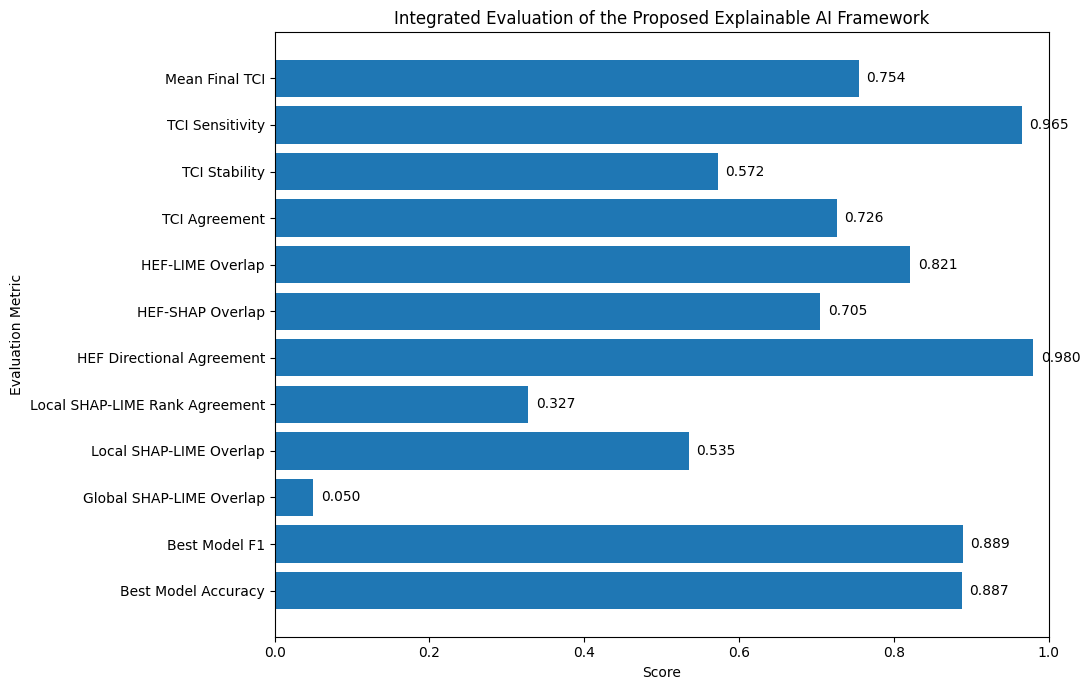

In [275]:
# Final Integrated Framework Visualisation
framework_visual = pd.DataFrame({
    "Metric": [
        "Best Model Accuracy",
        "Best Model F1",
        "Global SHAP-LIME Overlap",
        "Local SHAP-LIME Overlap",
        "Local SHAP-LIME Rank Agreement",
        "HEF Directional Agreement",
        "HEF-SHAP Overlap",
        "HEF-LIME Overlap",
        "TCI Agreement",
        "TCI Stability",
        "TCI Sensitivity",
        "Mean Final TCI"
    ],

    "Score": [
        final_model_comparison[
            "Accuracy"
        ].max(),

        final_model_comparison[
            "F1 Score"
        ].max(),

        global_overlap,

        agreement_df[
            "Top-10 Overlap"
        ].mean(),

        agreement_df[
            "Spearman Rho"
        ].mean(),

        hef_summary_df[
            "Directional Agreement Rate"
        ].mean(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        tci_agreement_df[
            "TCI Agreement Score"
        ].mean(),

        tci_stability_df[
            "LIME Stability Score"
        ].mean(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_final_df[
            "TCI"
        ].mean()
    ]
})

plt.figure(figsize=(11, 7))

bars = plt.barh(
    framework_visual["Metric"],
    framework_visual["Score"]
)

plt.xlabel("Score")
plt.ylabel("Evaluation Metric")

plt.title(
    "Integrated Evaluation of the Proposed Explainable AI Framework"
)

plt.xlim(0, 1)

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [276]:
# Statistical Validation Summary
statistical_validation_summary = pd.DataFrame({
    "Validation Analysis": [
        "TCI: Correct vs Incorrect Predictions",
        "TCI vs Prediction Confidence"
    ],

    "Statistical Test": [
        "Mann-Whitney U",
        "Spearman Correlation"
    ],

    "Statistic": [
        u_stat,
        confidence_rho
    ],

    "P-value": [
        p_value,
        confidence_p
    ],

    "Interpretation": [
        (
            "Significant difference"
            if p_value < 0.05
            else "No statistically significant difference"
        ),

        (
            "Significant positive association"
            if confidence_p < 0.05
            and confidence_rho > 0
            else "No statistically significant positive association"
        )
    ]
})

print("Statistical Validation of TCI")

display(
    statistical_validation_summary.round(4)
)

Statistical Validation of TCI


,Validation Analysis,Statistical Test,Statistic,P-value,Interpretation
0,TCI: Correct vs Incorrect Predictions,Mann-Whitney U,670.5000,0.0468,Significant difference
1,TCI vs Prediction Confidence,Spearman Correlation,0.3035,0.0021,Significant positive association


In [277]:
print("Current agreement_df verification")
print("---------------------------------")

print("Number of cases:",
      len(agreement_df))

print("Mean Top-10 Overlap:",
      agreement_df["Top-10 Overlap"].mean())

print("Median Top-10 Overlap:",
      agreement_df["Top-10 Overlap"].median())

print("Mean Spearman Rho:",
      agreement_df["Spearman Rho"].mean())

print("Median Spearman Rho:",
      agreement_df["Spearman Rho"].median())

print("Valid Spearman Cases:",
      agreement_df["Spearman Rho"].notna().sum())

Current agreement_df verification
---------------------------------
Number of cases: 100
Mean Top-10 Overlap: 0.535
Median Top-10 Overlap: 0.5
Mean Spearman Rho: 0.3272857142857142
Median Spearman Rho: 0.39999999999999997
Valid Spearman Cases: 100


# TASK 12: Robustness and Ablation Analysis

In [278]:
# HEF Fusion-Weight Sensitivity Analysis
weight_settings = [
    (0.1, 0.9),
    (0.3, 0.7),
    (0.5, 0.5),
    (0.7, 0.3),
    (0.9, 0.1)
]

weight_sensitivity_results = []

for shap_weight, lime_weight in weight_settings:

    case_overlaps = []
    top1_agreements = []

    for case_id in range(1, 101):

        case_df = hef_all_df[
            hef_all_df["Case"] == case_id
        ].copy()

        # Alternative HEF score
        case_df["Alternative HEF"] = (
            shap_weight
            * case_df["SHAP Normalised"]
            +
            lime_weight
            * case_df["LIME Normalised"]
        )

        # Alternative Top-10
        alternative_top10 = set(
            case_df
            .nlargest(
                10,
                "Alternative HEF"
            )["Symptom"]
        )

        # Baseline 50:50 HEF Top-10
        original_top10 = set(
            case_df
            .nlargest(
                10,
                "HEF Score"
            )["Symptom"]
        )

        overlap = (
            len(
                alternative_top10.intersection(
                    original_top10
                )
            )
            / 10
        )

        case_overlaps.append(
            overlap
        )

        # Compare Top-1 feature
        alternative_top1 = (
            case_df
            .nlargest(
                1,
                "Alternative HEF"
            )
            .iloc[0]["Symptom"]
        )

        original_top1 = (
            case_df
            .nlargest(
                1,
                "HEF Score"
            )
            .iloc[0]["Symptom"]
        )

        top1_agreements.append(
            alternative_top1
            ==
            original_top1
        )

    weight_sensitivity_results.append({
        "SHAP Weight": shap_weight,
        "LIME Weight": lime_weight,

        "Mean Top-10 Agreement with 50:50 HEF":
            np.mean(case_overlaps),

        "Median Top-10 Agreement with 50:50 HEF":
            np.median(case_overlaps),

        "Top-1 Agreement with 50:50 HEF":
            np.mean(top1_agreements)
    })


hef_weight_sensitivity_df = pd.DataFrame(
    weight_sensitivity_results
)

print(
    "HEF Fusion-Weight Sensitivity Analysis"
)

display(
    hef_weight_sensitivity_df.round(4)
)

HEF Fusion-Weight Sensitivity Analysis


,SHAP Weight,LIME Weight,Mean Top-10 Agreement with 50:50 HEF,Median Top-10 Agreement with 50:50 HEF,Top-1 Agreement with 50:50 HEF
0,0.1,0.9,0.830,0.8,0.68
1,0.3,0.7,0.896,0.9,0.79
2,0.5,0.5,1.000,1.0,1.00
3,0.7,0.3,0.867,0.9,0.87
4,0.9,0.1,0.765,0.8,0.82


In [280]:
# TCI Component Ablation Analysis
tci_ablation_df = (
    tci_validation_df
    .copy()
)

print(
    "TCI Ablation Cases:",
    len(tci_ablation_df)
)

# Full TCI
tci_ablation_df["Full TCI"] = (
    tci_ablation_df["TCI"]
)

# TCI without Agreement
tci_ablation_df[
    "TCI Without Agreement"
] = (
    tci_ablation_df[
        "LIME Stability Score"
    ]
    +
    tci_ablation_df[
        "Sensitivity Robustness Score"
    ]
) / 2


# TCI without Stability
tci_ablation_df[
    "TCI Without Stability"
] = (
    tci_ablation_df[
        "TCI Agreement Score"
    ]
    +
    tci_ablation_df[
        "Sensitivity Robustness Score"
    ]
) / 2


# TCI without Sensitivity
tci_ablation_df[
    "TCI Without Sensitivity"
] = (
    tci_ablation_df[
        "TCI Agreement Score"
    ]
    +
    tci_ablation_df[
        "LIME Stability Score"
    ]
) / 2


ablation_versions = [
    "Full TCI",
    "TCI Without Agreement",
    "TCI Without Stability",
    "TCI Without Sensitivity"
]

TCI Ablation Cases: 100


In [282]:
# TCI Ablation Validation Against Prediction Correctness
# TCI Ablation vs Prediction Confidence
ablation_results = []

for version in ablation_versions:

    rho, p = spearmanr(
        tci_ablation_df[version],
        tci_ablation_df[
            "Prediction Confidence"
        ]
    )

    ablation_results.append({
        "TCI Version": version,

        "Mean Score":
            tci_ablation_df[
                version
            ].mean(),

        "Spearman Rho with Confidence":
            rho,

        "P-value":
            p
    })


tci_ablation_summary = pd.DataFrame(
    ablation_results
)

print(
    "TCI Component Ablation Analysis"
)

display(
    tci_ablation_summary.round(4)
)

TCI Component Ablation Analysis


,TCI Version,Mean Score,Spearman Rho with Confidence,P-value
0,Full TCI,0.7545,0.3035,0.0021
1,TCI Without Agreement,0.7686,0.1287,0.2018
2,TCI Without Stability,0.8456,0.3167,0.0013
3,TCI Without Sensitivity,0.6492,0.3169,0.0013


In [283]:
# TCI Ablation Validation
# Against Prediction Correctness
from scipy.stats import mannwhitneyu

correctness_ablation_results = []

for version in ablation_versions:

    correct_scores = (
        tci_ablation_df.loc[
            tci_ablation_df[
                "Correct Prediction"
            ],
            version
        ]
    )

    incorrect_scores = (
        tci_ablation_df.loc[
            ~tci_ablation_df[
                "Correct Prediction"
            ],
            version
        ]
    )

    u, p = mannwhitneyu(
        correct_scores,
        incorrect_scores,
        alternative="two-sided"
    )

    correctness_ablation_results.append({
        "TCI Version": version,

        "Mean - Correct":
            correct_scores.mean(),

        "Mean - Incorrect":
            incorrect_scores.mean(),

        "Mean Difference":
            (
                correct_scores.mean()
                -
                incorrect_scores.mean()
            ),

        "Mann-Whitney U":
            u,

        "P-value":
            p
    })


tci_correctness_ablation_df = (
    pd.DataFrame(
        correctness_ablation_results
    )
)

print(
    "TCI Ablation Validation Against "
    "Prediction Correctness"
)

display(
    tci_correctness_ablation_df
    .round(4)
)

TCI Ablation Validation Against Prediction Correctness


,TCI Version,Mean - Correct,Mean - Incorrect,Mean Difference,Mann-Whitney U,P-value
0,Full TCI,0.7582,0.7248,0.0333,670.5,0.0468
1,TCI Without Agreement,0.7707,0.7514,0.0194,580.0,0.3211
2,TCI Without Stability,0.8502,0.8086,0.0416,692.0,0.0260
3,TCI Without Sensitivity,0.6535,0.6145,0.0390,645.0,0.0877


In [284]:
# Task 12 Robustness Summary

# alternative HEF weightings
alternative_hef_weights = (
    hef_weight_sensitivity_df[
        hef_weight_sensitivity_df[
            "SHAP Weight"
        ] != 0.5
    ]
)

task12_summary = pd.DataFrame({
    "Robustness Metric": [
        "Mean Alternative HEF Top-10 Agreement",
        "Minimum Alternative HEF Top-10 Agreement",
        "Mean Alternative HEF Top-1 Agreement",
        "Full TCI - Confidence Correlation",
        "Full TCI - Correctness P-value"
    ],

    "Value": [
        alternative_hef_weights[
            "Mean Top-10 Agreement with 50:50 HEF"
        ].mean(),

        alternative_hef_weights[
            "Mean Top-10 Agreement with 50:50 HEF"
        ].min(),

        alternative_hef_weights[
            "Top-1 Agreement with 50:50 HEF"
        ].mean(),

        tci_ablation_summary.loc[
            tci_ablation_summary[
                "TCI Version"
            ] == "Full TCI",
            "Spearman Rho with Confidence"
        ].iloc[0],

        tci_correctness_ablation_df.loc[
            tci_correctness_ablation_df[
                "TCI Version"
            ] == "Full TCI",
            "P-value"
        ].iloc[0]
    ]
})

print(
    "Task 12: Robustness and Ablation Summary"
)

display(
    task12_summary.round(4)
)

Task 12: Robustness and Ablation Summary


,Robustness Metric,Value
0,Mean Alternative HEF Top-10 Agreement,0.8395
1,Minimum Alternative HEF Top-10 Agreement,0.7650
2,Mean Alternative HEF Top-1 Agreement,0.7900
3,Full TCI - Confidence Correlation,0.3035
4,Full TCI - Correctness P-value,0.0468


# TASK 13: Final Results Consolidation and Reproducibility

In [285]:
# Master Results Table

In [290]:
master_results = pd.DataFrame({
    "Analysis Stage": [
        "Predictive Modelling",
        "Predictive Modelling",

        "XAI Agreement",
        "XAI Agreement",
        "XAI Agreement",

        "HEF",
        "HEF",
        "HEF",

        "TCI",
        "TCI",
        "TCI",
        "TCI",
        "TCI",

        "TCI Validation",
        "TCI Validation",

        "HEF Robustness",
        "TCI Ablation"
    ],

    "Metric": [
        "Best Model Accuracy",
        "Best Model F1 Score",

        "Global SHAP-LIME Top-20 Overlap",
        "Mean Local SHAP-LIME Top-10 Overlap",
        "Mean Local SHAP-LIME Spearman Correlation",

        "Mean Directional Agreement",
        "Mean HEF-SHAP Top-10 Overlap",
        "Mean HEF-LIME Top-10 Overlap",

        "Mean Agreement Component",
        "Mean LIME Stability Component",
        "Mean SHAP Sensitivity Robustness",
        "Prediction Preservation Rate",
        "Mean Final TCI",

        "Correct vs Incorrect TCI P-value",
        "TCI-Confidence Spearman Correlation",

        "Moderate HEF Weighting Top-1 Agreement",
        "Full TCI Correct-Incorrect Mean Difference"
    ],

    "Value": [
        # Predictive modelling
        final_model_comparison[
            "Accuracy"
        ].max(),

        final_model_comparison[
            "F1 Score"
        ].max(),

        # XAI
        0.05,

        agreement_df[
            "Top-10 Overlap"
        ].mean(),

        agreement_df[
            "Spearman Rho"
        ].mean(),

        # HEF
        hef_summary_df[
            "Directional Agreement Rate"
        ].mean(),

        hef_validation_df[
            "HEF-SHAP Top-10 Overlap"
        ].mean(),

        hef_validation_df[
            "HEF-LIME Top-10 Overlap"
        ].mean(),

        # TCI
        tci_agreement_df[
            "TCI Agreement Score"
        ].mean(),

        tci_stability_df[
            "LIME Stability Score"
        ].mean(),

        tci_sensitivity_df[
            "Sensitivity Robustness Score"
        ].mean(),

        tci_sensitivity_df[
            "Prediction Preserved"
        ].mean(),

        tci_final_df[
            "TCI"
        ].mean(),

        # TCI validation
        p_value,

        confidence_rho,

        # HEF robustness:
        # average Top-1 agreement for 30:70 and 70:30
        hef_weight_sensitivity_df.loc[
            hef_weight_sensitivity_df[
                "SHAP Weight"
            ].isin([0.3, 0.7]),
            "Top-1 Agreement with 50:50 HEF"
        ].mean(),

        # TCI ablation / correctness
        correct_tci.mean()
        -
        incorrect_tci.mean()
    ]
})

print("MASTER DISSERTATION RESULTS")

display(
    master_results.round(4)
)

MASTER DISSERTATION RESULTS


,Analysis Stage,Metric,Value
0,Predictive Modelling,Best Model Accuracy,0.8875
1,Predictive Modelling,Best Model F1 Score,0.8887
2,XAI Agreement,Global SHAP-LIME Top-20 Overlap,0.0500
3,XAI Agreement,Mean Local SHAP-LIME Top-10 Overlap,0.5350
4,XAI Agreement,Mean Local SHAP-LIME Spearman Correlation,0.3273
5,HEF,Mean Directional Agreement,0.9801
6,HEF,Mean HEF-SHAP Top-10 Overlap,0.7050
7,HEF,Mean HEF-LIME Top-10 Overlap,0.8210
8,TCI,Mean Agreement Component,0.7263
9,TCI,Mean LIME Stability Component,0.5722


In [287]:
# Reproducibility Information

In [288]:
import sys
import numpy as np
import pandas as pd
import sklearn
import xgboost
import shap
import lime


print("REPRODUCIBILITY INFORMATION")

print(
    "Python Version       :",
    sys.version.split()[0]
)

print(
    "NumPy Version        :",
    np.__version__
)

print(
    "Pandas Version       :",
    pd.__version__
)

print(
    "Scikit-learn Version :",
    sklearn.__version__
)

print(
    "XGBoost Version      :",
    xgboost.__version__
)

print(
    "SHAP Version         :",
    shap.__version__
)


print("\nExperimental Configuration")

print(
    "Primary Random State :",
    42
)

print(
    "XAI Evaluation Cases :",
    len(X_xai_sample)
)

print(
    "Number of Features   :",
    len(feature_names)
)

print(
    "Disease Classes      :",
    len(label_encoder.classes_)
)


print("\nXAI Configuration")

print(
    "SHAP Method          : TreeExplainer"
)

print(
    "LIME Mode            : Classification"
)

print(
    "LIME Features        : Binary/Categorical"
)

print(
    "Local Explanation K  :",
    10
)


print("\nHEF Configuration")

print(
    "SHAP Weight          :",
    0.5
)

print(
    "LIME Weight          :",
    0.5
)

print(
    "Fusion Strategy      : Equal-weight L1-normalised fusion"
)


print("\nTCI Configuration")

print(
    "Agreement Components : "
    "Top-10 overlap, rank agreement, direction"
)

print(
    "LIME Stability Runs  :",
    5
)

print(
    "Sensitivity Method   : "
    "Binary feature flipping"
)

print(
    "Perturbation Rate    :",
    0.02
)

print(
    "Features Flipped     :",
    5
)

print(
    "Total TCI Cases      :",
    len(tci_final_df)
)

print(
    "Prediction Preservation Rate:",
    round(
        tci_final_df[
            "Prediction Preserved"
        ].mean(),
        4
    )
)

REPRODUCIBILITY INFORMATION
Python Version       : 3.13.9
NumPy Version        : 2.1.3
Pandas Version       : 2.3.3
Scikit-learn Version : 1.8.0
XGBoost Version      : 3.1.1
SHAP Version         : 0.51.0

Experimental Configuration
Primary Random State : 42
XAI Evaluation Cases : 100
Number of Features   : 230
Disease Classes      : 100

XAI Configuration
SHAP Method          : TreeExplainer
LIME Mode            : Classification
LIME Features        : Binary/Categorical
Local Explanation K  : 10

HEF Configuration
SHAP Weight          : 0.5
LIME Weight          : 0.5
Fusion Strategy      : Equal-weight L1-normalised fusion

TCI Configuration
Agreement Components : Top-10 overlap, rank agreement, direction
LIME Stability Runs  : 5
Sensitivity Method   : Binary feature flipping
Perturbation Rate    : 0.02
Features Flipped     : 5
Total TCI Cases      : 100
Prediction Preservation Rate: 0.72


In [289]:
# Final Computational Pipeline Verification
verification_checks = {

    "Model comparison available":
        "final_model_comparison"
        in globals(),

    "SHAP-LIME agreement available":
        "agreement_df"
        in globals(),

    "Global SHAP importance available":
        "shap_importance_df"
        in globals(),

    "Global LIME importance available":
        "lime_importance_df"
        in globals(),

    "HEF systematic results available":
        "hef_all_df"
        in globals(),

    "HEF validation available":
        "hef_validation_df"
        in globals(),

    "TCI agreement available":
        "tci_agreement_df"
        in globals(),

    "TCI stability available":
        "tci_stability_df"
        in globals(),

    "TCI sensitivity available":
        "tci_sensitivity_df"
        in globals(),

    "Final TCI available":
        "tci_final_df"
        in globals(),

    "TCI validation available":
        "tci_validation_df"
        in globals(),

    "HEF robustness available":
        "hef_weight_sensitivity_df"
        in globals(),

    "TCI ablation available":
        "tci_ablation_summary"
        in globals(),

    "Integrated framework available":
        "framework_summary"
        in globals(),

    "Master results available":
        "master_results"
        in globals()
}


verification_df = pd.DataFrame({
    "Pipeline Component":
        verification_checks.keys(),

    "Available":
        verification_checks.values()
})


print(
    "FINAL COMPUTATIONAL PIPELINE VERIFICATION"
)

display(
    verification_df
)

FINAL COMPUTATIONAL PIPELINE VERIFICATION


,Pipeline Component,Available
0,Model comparison available,True
1,SHAP-LIME agreement available,True
2,Global SHAP importance available,True
3,Global LIME importance available,True
4,HEF systematic results available,True
5,HEF validation available,True
6,TCI agreement available,True
7,TCI stability available,True
8,TCI sensitivity available,True
9,Final TCI available,True
